**Installations**

Uncomment and run, the first time you use this notebook.

In [1]:
! pip install seaborn
! pip install pycirclize
! pip install plotly networkx
! pip install -U kaleido
! pip install -U plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB 660.6 kB/s eta 0:00:15
   -- ------------------------------------- 0.6/9.9 MB 5.9 MB/s eta 0:00:02
   -------------- ------------------------- 3.6/9.9 MB 28.3 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.9 MB 35.0 MB/s eta 0:00:01
   --------------------------------- ------ 8.2/9.9 MB 40.3 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 42.3 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 6.7.0
    Uninstalling plotly-6.7.0:
      Successfully uninstalled plotly-6.7.0


In [ ]:
!pip install --upgrade nbformat

In [2]:
# Imports

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.patches import Rectangle, Patch
import matplotlib.pyplot as plt
import matplotlib as mpl
import pycirclize
#from pycirclize import Circos
from matplotlib.colors import LinearSegmentedColormap, to_hex, TwoSlopeNorm
import matplotlib.cm as cm
import matplotlib
from matplotlib.collections import LineCollection
import os
import plotly.graph_objects as go
import networkx as nx
import plotly.express as px
import plotly.io as pio
from collections import defaultdict
from itertools import combinations
import math
from plotly.colors import sample_colorscale
import os
import h5py
from sklearn.manifold import TSNE
import glasbey
import re
from collections import Counter
from scipy.cluster.hierarchy import dendrogram
from scipy.stats import entropy
from scipy.spatial.distance import jensenshannon
from scipy.spatial.distance import cosine

**File directories**

Make changes for the input and output paths and directories here.

In [46]:
# Input files used for analysis
Cluster_detail_results = pd.read_csv( os.path.join(r'Y:\3darena_behavior\wildtype_062425\011625_5\011625_5_open_arena_052125\2h_combined_results\Results\test1\Cluster_detail_results.csv') )
mat_filename = r"Y:\3darena_behavior\wildtype_062425\011625_5\011625_5_open_arena_052125\2h_combined_results\Results\test1\session_1_out.mat"
filename_groups = r'Y:\3darena_behavior\wildtype_062425\011625_5\011625_5_open_arena_052125\2h_combined_results\Results\test1\cluster_groups_matlab.csv'
linkage_matrix_path = r"Y:\3darena_behavior\wildtype_062425\011625_5\011625_5_open_arena_052125\2h_combined_results\Results\test1\linkage_matlab.csv"

# Output directory for all data
output_path = r"Y:\3darena_behavior\wildtype_062425\011625_5\011625_5_open_arena_052125\2h_combined_results\Results\test1"
os.makedirs(output_path, exist_ok=True)

# Output directory for all Graphs
output_dir = r'Y:\3darena_behavior\wildtype_062425\011625_5\011625_5_open_arena_052125\2h_combined_results\graphs'
os.makedirs(output_dir, exist_ok=True)

# Use any label for mouse
mouse_name = "openf"  

Stitched Labeled Experiment - Create combined_matrix.csv before creating visuals

In [47]:
# --------------------------- Extracting 4 Features --------
def find_path_to_key(h5_obj, target_key, path=""):
    for key in h5_obj.keys():
        new_path = f"{path}/{key}"
        if key == target_key:
            return new_path
        if isinstance(h5_obj[key], h5py.Group):
            result = find_path_to_key(h5_obj[key], target_key, new_path)
            if result is not None:
                return result
    return None


def load_funct_features(filepath):
    with h5py.File(filepath, "r") as f:
        struct_path = find_path_to_key(f, "StructData")
        if struct_path is None:
            raise KeyError("Could not find 'StructData' in MAT file.")

        struct_group = f[struct_path]

        if "func" not in struct_group:
            raise KeyError("'func' not found inside StructData.")

        func = struct_group["func"]
 
        # MATLAB {1,1-4} -> Python func[0-3][0]
        feature_refs = [func[i][0] for i in range(4)]
        feature_arrays = []
        for ref in feature_refs:
            arr = f[ref][()]  # Dereference dataset
            arr = np.array(arr).squeeze()
            feature_arrays.append(arr)
        
        return np.vstack(feature_arrays)


def combine_results(mat_file, cb_matrix, output_file="combined_results_with_features.csv"):
    features = load_funct_features(mat_file)
    
    # ---- NEW: average every 60 samples ----
    n_samples = features.shape[1]
    if n_samples % 60 != 0:
        raise ValueError("Number of samples is not divisible by 60.")


    log_tot_accel = features[3]
    exp_log_tot_accel = np.exp(log_tot_accel)
    averaged_tot_accel = exp_log_tot_accel.reshape(-1, 60).mean(axis=1)

    features_reshaped = features.reshape(4, -1, 60)
    features_avg = features_reshaped.mean(axis=2)

    full_feature_df = pd.DataFrame()
    full_feature_df["anterior_posterior_x_accel"] = features[0]
    full_feature_df["dorsal_ventral_y_accel"] = features[1]
    full_feature_df["y_gyro"] = features[2]
    full_feature_df["TotAccelBA"] = features[3]

    df = cb_matrix.copy()

    if len(df) != features_avg.shape[1]:
        raise ValueError(
            f"CSV rows ({len(df)}) do not match averaged func length ({features_avg.shape[1]})."
        )

    df["anterior_posterior_x_accel"] = features_avg[0]
    df["dorsal_ventral_y_accel"] = features_avg[1]
    df["y_gyro"] = features_avg[2]
    df["TotAccelBA"] = averaged_tot_accel

    df.to_csv(output_file, index=False)
    full_feature_df.to_csv(os.path.join(output_path, "full_feature.csv"), index=False)
    print("Saved:", output_file)
    return df

In [48]:
grouped_clusters = pd.read_csv(filename_groups)

# Read in values from clustersIdx, set automatically to the cluster value it represents rather than the actual value of the cell
if os.path.exists(mat_filename):
    with h5py.File(mat_filename, 'r') as file:
        library = file['Library']
        clustersIdx = library['clustersIdx']
        
        group_labels = []
        for i in range(clustersIdx.shape[0]):
            idxref = clustersIdx[i, 0]
            cluster_indices = np.array(file[idxref]).flatten()
            group_labels.extend([i+1] * len(cluster_indices))
        
        group_labels_df = pd.DataFrame(group_labels, columns=['GroupLabel'])
        print(f"Group labels shape: {group_labels_df.shape}")
else:
    raise FileNotFoundError('Could not find session_1_out.mat in dedicated subdirectory')


# Read in the feature values from clusters and stack on top of each other
if os.path.exists(mat_filename):
    print('Loading session file from expected Results/test1 directory')
    with h5py.File(mat_filename, 'r') as file:
        if 'Library' not in file:
            raise KeyError("The key 'Library' was not found in the session file.")
        library = file['Library']
        clusters = library['clusters']
        
        features_data = []
        
        for i in range(clusters.shape[0]):
            cref = clusters[i, 0]
            feature_data = np.array(file[cref]).T 
            features_data.append(feature_data)
        
        features_matrix = np.vstack(features_data)
        features_df = pd.DataFrame(features_matrix)
        print(f"Loaded {len(features_data)} clusters with total points: {features_matrix.shape[0]}")
        print(f"Combined matrix shape: {features_matrix.shape}")
else:
    raise FileNotFoundError('Could not find session_1_out.mat in dedicated subdirectory')
features_df['cluster'] = group_labels_df['GroupLabel'].values

# Create combined matrix by matching first occurrence of each cluster in features_df to first occurrence in Cluster_detail_results, keeping order of Cluster_detail_results
def match_features_to_details(features_df, detail_df):
    matched_rows = []
    cluster_counts = {}
    for idx, detail_row in detail_df.iterrows():
        # print("combining")
        cluster_val = detail_row['ClusterIdx']
        count = cluster_counts.get(cluster_val, 0)
        feature_rows = features_df[features_df['cluster'] == cluster_val]
        if count < len(feature_rows):
            feature_row = feature_rows.iloc[count]
            combined_row = feature_row.to_dict()
            combined_row['Timestamp'] = detail_row['Timestamp'] if 'Timestamp' in detail_row else None
            combined_row['ClusterIdx'] = cluster_val
            combined_row['Folder_Name'] = detail_row['Folder_Name'] if 'Folder_Name' in detail_row else None
            matched_rows.append(combined_row)
            cluster_counts[cluster_val] = count + 1
        else:
            combined_row = {col: None for col in features_df.columns}
            combined_row['Timestamp'] = detail_row['Timestamp'] if 'Timestamp' in detail_row else None
            combined_row['ClusterIdx'] = cluster_val
            combined_row['Folder_Name'] = detail_row['Folder_Name'] if 'Folder_Name' in detail_row else None
            matched_rows.append(combined_row)
    return pd.DataFrame(matched_rows)
combined_matrix = match_features_to_details(features_df, Cluster_detail_results)

# Automatically detects Week_Number from Folder_Name based on pattern of 'weekXX'
def get_week_number(folder_name):
    if isinstance(folder_name, str):
        match = re.search(r'week(\d+)', folder_name)
        if match:
            return int(match.group(1))
        
        # testing for arenas
        folder_name_lower = folder_name.lower()
        
        if "baseline" in folder_name_lower:
            return 1
        elif "inhibition" in folder_name_lower:
            return 2
    elif isinstance(folder_name, (float, int)):
        return int(folder_name)
    return None

combined_matrix['Folder_Name'] = combined_matrix['Folder_Name'].ffill()
combined_matrix['Week_Number'] = combined_matrix['Folder_Name'].apply(get_week_number)
# Forward fill missing Week_Number values
#combined_matrix['Week_Number'] = combined_matrix['Week_Number'].dropna().astype(int)

# Clean up the finalized combined df (Column Titles : "Feature 1" ... "Feature 30" , "Timestamp" , "Cluster", "Week_Number", "Group")
feature_cols = {i: f'Feature{i+1}' for i in range(30)}
combined_matrix = combined_matrix.rename(columns=feature_cols)
combined_matrix = combined_matrix.drop(columns=['cluster'])
#combined_matrix = combined_matrix.drop(columns=['Folder_Name'])
combined_matrix = combined_matrix.rename(columns={'ClusterIdx': 'Cluster'})

combined_matrix["Group"] = combined_matrix["Cluster"].map(
    grouped_clusters.set_index("Cluster")["Group"]
)

combined_matrix = combined_matrix.sort_values(by='Week_Number')
# Save combined_matrix file
output_file = os.path.join(output_path, f"combined_matrix_{mouse_name}.csv")
combined_matrix.to_csv(output_file, index=False)
combined_matrix = combine_results(mat_filename, combined_matrix, output_file=os.path.join(output_path, f"combined_results_{mouse_name}_with_features.csv"))
print(f"Saved as {output_file}")
print(combined_matrix.head())

Group labels shape: (23834, 1)
Loading session file from expected Results/test1 directory
Loaded 40 clusters with total points: 23834
Combined matrix shape: (23834, 30)
Saved: Y:\3darena_behavior\wildtype_062425\011625_5\011625_5_open_arena_052125\2h_combined_results\Results\test1\combined_results_openf_with_features.csv
Saved as Y:\3darena_behavior\wildtype_062425\011625_5\011625_5_open_arena_052125\2h_combined_results\Results\test1\combined_matrix_openf.csv
   Feature1  Feature2  Feature3  Feature4  Feature5  Feature6  Feature7  \
0       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
1       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
2       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
3       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
4       0.0       0.0       0.0       0.0       0.0       0.0       0.0   

   Feature8  Feature9  Feature10  ...  Feature29  Feature30  Timestamp  \
0       0.0

**Function Definitions**

In [ ]:
# -------------------- t-SNE --------------------
# Automatically find the number of stages
weeks = combined_matrix['Week_Number'].unique()
stage_names = [f"Stage {i}" for i in range(1, len(weeks) + 1)]

# Automatically find the total number of clusters
num_clusters = combined_matrix['Cluster'].max()

# Compute t-SNE embedding (if not precomputed)
# features = combined_matrix.iloc[:, 0:30].values.astype(float)
features = combined_matrix.iloc[:, 35:39].values.astype(float)
tsne = TSNE(n_components=2, perplexity=30, learning_rate=100, random_state=42)
Y = tsne.fit_transform(features)
combined_matrix['TSNE-1'] = Y[:, 0]
combined_matrix['TSNE-2'] = Y[:, 1]

# Get all clusters present across the ENTIRE dataset
all_clusters = sorted(combined_matrix['Cluster'].unique())
cluster_labels_str = [str(c) for c in all_clusters]

# Create color pallette
glasbey_palette = glasbey.create_palette(palette_size=num_clusters)
cluster_to_color = {
    str(c): glasbey_palette[int(i % num_clusters)]
    for i, c in enumerate(all_clusters)
}

In [7]:
#-------------- Grouped TSNE Plots --------------------------
# Automatically find the total number of clusters
num_clusters_group = combined_matrix['Group'].max()

# Get all clusters present across the ENTIRE dataset
all_clusters_group = sorted(combined_matrix['Group'].unique())
cluster_labels_str_group = [str(c) for c in all_clusters_group]

# Create color pallette
glasbey_palette_group = glasbey.create_palette(palette_size=num_clusters_group)
cluster_to_color_group = {
    str(c): glasbey_palette_group[int(i % num_clusters_group)]
    for i, c in enumerate(all_clusters_group)
}

In [ ]:
# -------------------- Circular Heatmap --------------------
def create_cluster_usage_df( df ):
    df = pd.DataFrame( df )

    df_cluster_usage = df['Cluster'].value_counts().reset_index()
    df_cluster_usage.columns = ['Cluster', 'count']
    df_cluster_usage['count'] = df_cluster_usage['count'].astype( int )
    total_count = df_cluster_usage['count'].sum()
    df_cluster_usage['percentage'] = df_cluster_usage['count'] / total_count * 100

    return df_cluster_usage

def create_group_usage_df( df ):
    df = pd.DataFrame( df )

    df_group_usage = df['Group'].value_counts().reset_index()
    df_group_usage.columns = ['Group' , 'count' ]
    df_group_usage['count'] = df_group_usage['count'].astype( int )
    total_count = df_group_usage['count'].sum()
    df_group_usage['percentage'] = df_group_usage['count'] / total_count * 100

    return df_group_usage

def compute_cluster_usage_change( week_dfs, week_early, week_late ):

    df_early = week_dfs[week_early]
    df_late = week_dfs[week_late]

    merged_df = pd.merge(
        df_early, df_late,
        on='Cluster', how='right',
        suffixes=(f'_{week_early}', f'_{week_late}')
    )

    merged_df[f'percentage_{week_early}'] = merged_df[f'percentage_{week_early}'].fillna(0)
    merged_df['change_in_usage'] = merged_df[f'percentage_{week_late}'] - merged_df[f'percentage_{week_early}']

    return merged_df[['Cluster', f'percentage_{week_early}', f'percentage_{week_late}', 'change_in_usage']]

def compute_group_usage_changes(week_dfs, week_early, week_late ):
    df_early = week_dfs[week_early]
    df_late = week_dfs[week_late]

    merged_df = pd.merge(
        df_early, df_late,
        on='Group', how='right',
        suffixes=(f'_{week_early}', f'_{week_late}')
    )

    merged_df[f'percentage_{week_early}'] = merged_df[f'percentage_{week_early}'].fillna(0)
    merged_df['change_in_usage'] = merged_df[f'percentage_{week_late}'] - merged_df[f'percentage_{week_early}']

    return merged_df[['Group', f'percentage_{week_early}', f'percentage_{week_late}', 'change_in_usage']]

def create_circular_heatmaps_variable_periods(
    dfs,
    save=False,
    paths=None,
    global_min=None,
    global_max=None,
    keys=None
):
   
    # Filter each DataFrame to same cluster range
    dfs = [df[(df['Cluster'] >= 1) & (df['Cluster'] <= 72)] for df in dfs]

    # Determine global color scale across all DataFrames
    all_changes = np.concatenate([df['change_in_usage'].values for df in dfs])
    if global_min is None:
        global_min = all_changes.min()
    if global_max is None:
        global_max = all_changes.max()

    # global_min = -4.774236665
    # global_max = 4.531974437158014

    norm = TwoSlopeNorm(vmin=global_min, vcenter=0, vmax=global_max)

    # Determine consistent cluster order (based on ascending ClusterNumber)
    all_clusters = sorted(set(np.concatenate([df['Cluster'].unique() for df in dfs])))

    def convert_key_to_stage_label(key):
        tokens = key.split("_")
        stage_nums = []

        for t in tokens:
            # extract digits from token (e.g., "week12" → "12")
            digits = ''.join(ch for ch in t if ch.isdigit())
            if digits:
                stage_nums.append(int(digits))
        
        # Safety check: must have 2 stages
        if len(stage_nums) != 2:
            return key  # fallback
        
        return f"Stage {stage_nums[0]} → Stage {stage_nums[1]}"


    titles = [
        f"Change in Cluster Usage Percentage - {convert_key_to_stage_label(key)}"
        for key in keys
    ]

    # Iterate through each DataFrame
    for i, df in enumerate(dfs):
        # Reorder to consistent cluster order
        df_ordered = (
            df.set_index("Cluster")
              .reindex(all_clusters)
              .fillna({"change_in_usage": 0})
              .reset_index()
        )

        clusters = df_ordered["Cluster"].astype(int).values
        change_values = df_ordered["change_in_usage"].values
        colors = plt.cm.bwr(norm(change_values))

        # Create polar plot
        fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"})
        theta = np.linspace(0, 2 * np.pi, len(clusters), endpoint=False)
        slice_width = 2 * np.pi / len(clusters)
        bar_width = slice_width * 0.9
        ax.bar(theta, np.ones(len(clusters)), color=colors, width=bar_width, bottom=0.5)

        # Axis formatting
        ax.set_xticks(theta)
        ax.set_xticklabels(clusters, fontsize=5.5, rotation=45)
        ax.set_yticklabels([])
        ax.set_yticks([])
        ax.tick_params(axis="x", pad=-8)
        ax.grid(False)
        ax.spines["polar"].set_visible(False)

        # Colorbar (same normalization across all plots)
        sm = plt.cm.ScalarMappable(cmap="bwr", norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", pad=0.1)
        cbar.set_label("Change in Usage Percentage")

        plt.title(titles[i])
        plt.tight_layout()

        # --- Optional saving
        if save and paths and i < len(paths):
            path = paths[i]
            eps_dir = os.path.dirname(path)
            if eps_dir:
                os.makedirs(eps_dir, exist_ok=True)

            base_filename = os.path.splitext(os.path.basename(path))[0]
            eps_path = os.path.join(eps_dir, base_filename + ".eps")
            plt.savefig(eps_path, format="eps", bbox_inches="tight")
            print(f"EPS saved to: {eps_path}")

            parent_dir = os.path.dirname(eps_dir)
            png_dir = os.path.join(parent_dir, "png")
            os.makedirs(png_dir, exist_ok=True)
            png_path = os.path.join(png_dir, base_filename + ".png")
            plt.savefig(png_path, format="png", dpi=300, bbox_inches="tight")
            print(f"PNG saved to: {png_path}")

        plt.show()

def create_group_heatmaps_variable_periods(
    dfs,
    save=False,
    paths=None,
    global_min=None,
    global_max=None,
    keys=None
):
    dfs = [df[df['Group'] >= 1] for df in dfs]

    all_changes = np.concatenate([df['change_in_usage'].values for df in dfs])
    if global_min is None:
        global_min = all_changes.min()
    if global_max is None:
        global_max = all_changes.max()

    norm = TwoSlopeNorm(vmin=global_min, vcenter=0, vmax=global_max)

    # Determine consistent group ordering
    all_groups = sorted(set(np.concatenate([df['Group'].unique() for df in dfs])))

    def convert_key_to_stage_label(key):
        tokens = key.split("_")
        stage_nums = []

        for t in tokens:
            digits = ''.join(ch for ch in t if ch.isdigit())
            if digits:
                stage_nums.append(int(digits))

        if len(stage_nums) != 2:
            return key  # fallback

        return f"Stage {stage_nums[0]} → Stage {stage_nums[1]}"

    titles = [
        f"Change in Group Usage Percentage - {convert_key_to_stage_label(key)}"
        for key in keys
    ]

    # Plot heatmaps
    for i, df in enumerate(dfs):

        df_ordered = (
            df.set_index("Group")
              .reindex(all_groups)
              .fillna({"change_in_usage": 0})
              .reset_index()
        )

        groups = df_ordered["Group"].astype(int).values
        change_values = df_ordered["change_in_usage"].values
        colors = plt.cm.bwr(norm(change_values))

        # Create circular heatmap
        fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"})
        theta = np.linspace(0, 2 * np.pi, len(groups), endpoint=False)
        slice_width = 2 * np.pi / len(groups)
        bar_width = slice_width * 0.9

        ax.bar(theta, np.ones(len(groups)), color=colors, width=bar_width, bottom=0.5)

        # Axis formatting
        ax.set_xticks(theta)
        ax.set_xticklabels(groups, fontsize=6, rotation=45)
        ax.set_yticklabels([])
        ax.set_yticks([])
        ax.tick_params(axis="x", pad=-8)
        ax.grid(False)
        ax.spines["polar"].set_visible(False)

        # Colorbar
        sm = plt.cm.ScalarMappable(cmap="bwr", norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", pad=0.1)
        cbar.set_label("Change in Usage Percentage")

        plt.title(titles[i])
        plt.tight_layout()

        # Optional saving
        if save and paths and i < len(paths):
            path = paths[i]
            eps_dir = os.path.dirname(path)
            if eps_dir:
                os.makedirs(eps_dir, exist_ok=True)

            base_filename = os.path.splitext(os.path.basename(path))[0]
            eps_path = os.path.join(eps_dir, base_filename + ".eps")
            plt.savefig(eps_path, format="eps", bbox_inches="tight")
            print(f"EPS saved to: {eps_path}")

            parent_dir = os.path.dirname(eps_dir)
            png_dir = os.path.join(parent_dir, "png")
            os.makedirs(png_dir, exist_ok=True)
            png_path = os.path.join(png_dir, base_filename + ".png")
            plt.savefig(png_path, format="png", dpi=300, bbox_inches="tight")
            print(f"PNG saved to: {png_path}")

        plt.show()

def create_normal_heatmaps_combined(
    dfs,
    save=False,
    paths=None,
    global_min=None,
    global_max=None,
    keys=None
):
    # Filter each DataFrame to consistent cluster range
    dfs = [df[(df['Cluster'] >= 1) & (df['Cluster'] <= 72)] for df in dfs]

    # Global normalization
    all_changes = np.concatenate([df['change_in_usage'].values for df in dfs])
    if global_min is None:
        global_min = all_changes.min()
    if global_max is None:
        global_max = all_changes.max()

    norm = TwoSlopeNorm(vmin=global_min, vcenter=0, vmax=global_max)

    # Consistent cluster ordering
    all_clusters = sorted(set(np.concatenate([df['Cluster'].unique() for df in dfs])))

    # Label converter
    def convert_key_to_stage_label(key):
        tokens = key.split("_")
        nums = [''.join(ch for ch in t if ch.isdigit()) for t in tokens]
        nums = [int(x) for x in nums if x.isdigit()]
        if len(nums) == 2:
            return f"Stage {nums[0]} → Stage {nums[1]}"
        return key

    titles = [f"{convert_key_to_stage_label(k)}"
              for k in keys]

    n = len(dfs)

    # Tighter figure layout
    fig, axes = plt.subplots(
        n, 1,
        figsize=(14, 1.2 * n),    
        sharex=True,
        constrained_layout=False
    )

    fig.suptitle(f"Change in Cluster Usage for {mouse_name}", fontsize=14, y=1.02)  

    if n == 1:
        axes = [axes]

    for i, (df, ax) in enumerate(zip(dfs, axes)):

        df_ordered = (
            df.set_index("Cluster")
              .reindex(all_clusters)
              .fillna({"change_in_usage": 0})
              .reset_index()
        )

        vals = df_ordered["change_in_usage"].values.reshape(1, -1)

        im = ax.imshow(
            vals,
            cmap="bwr",
            norm=norm,
            aspect="auto",
            interpolation="none" 
        )

        for spine in ["top", "bottom", "left", "right"]:
            ax.spines[spine].set_visible(False)

        # Left-side clean label (aligned vertically)
        ax.set_ylabel(
            titles[i],
            rotation=0,
            fontsize=9,
            ha="right",
            va="center",
            labelpad=25
        )

        ax.set_yticks([])

    # X-axis ticks only on bottom
    axes[-1].set_xticks(np.arange(len(all_clusters)))
    axes[-1].set_xticklabels(all_clusters, rotation=70, fontsize=6)

    plt.subplots_adjust(hspace=0.0025)

    # Colorbar
    cbar = fig.colorbar(
        im, ax=axes,
        orientation="horizontal",
        fraction=0.05, pad=0.1
    )
    cbar.set_label("Change in Usage Percentage")

    # --- Save ---
    if save and paths:
        path = paths[0]
        eps_dir = os.path.dirname(path)
        if eps_dir:
            os.makedirs(eps_dir, exist_ok=True)

        base = os.path.splitext(os.path.basename(path))[0]

        eps_path = os.path.join(eps_dir, base + ".eps")
        fig.savefig(eps_path, format="eps", bbox_inches="tight")

        png_dir = os.path.join(os.path.dirname(eps_dir), "png")
        os.makedirs(png_dir, exist_ok=True)
        png_path = os.path.join(png_dir, base + ".png")
        fig.savefig(png_path, format="png", dpi=300, bbox_inches="tight")

    plt.show()

In [ ]:
# -------------------- Circular Heatmap --------------------
all_df = combined_matrix
week_map = {wk: i+1 for i, wk in enumerate(sorted(all_df["Week_Number"].unique()))}
all_df["Week_Number"] = combined_matrix["Week_Number"].replace(week_map)

# Creates list of dfs, one for each unique week within the dataset
stage_dfs = {
    f"stage{int(week)}": group_df.sort_values(by="Cluster", ascending=True).copy()
    for week, group_df in all_df.groupby("Week_Number", sort=True)
}

In [ ]:
# -------------------- Cluster Level Char --------------------
## Calculate time spent in each cluster - Start Time, End Time, Duration, Cluster, Folder Name
def extract_bouts(df):
    df = df.reset_index(drop=True)
    change = df['Cluster'] != df['Cluster'].shift()
    starts = df.index[change]
    ends = list(starts[1:]) + [len(df)-1]

    bout_data = []
    for start, end in zip(starts, ends):
        duration = df.loc[end, 'Timestamp'] - df.loc[start, 'Timestamp'] + 1
        bout_data.append({
            'start_timestamp': df.loc[start, 'Timestamp'],
            'end_timestamp': df.loc[end, 'Timestamp'],
            'duration': duration,
            'Cluster': df.loc[start, 'Cluster'],
            'Week_Number': df.loc[start, 'Week_Number']
        })
    return pd.DataFrame(bout_data)

In [ ]:
# -------------------- Cluster Level Char --------------------
def plot_week_vs_week(g, stage_left=8, stage_right=12, ax=None,
                      color_left='#d3d3d3', color_right='#f08080'):
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 6))

    base = g[g['Week_Number'] == stage_left].copy()
    base = base.sort_values('pct', ascending=False)
    clusters = base['Cluster'].to_numpy()[::-1]

    left = base.set_index('Cluster').loc[clusters, 'pct'].fillna(0)
    left = -left

    right_week = g[g['Week_Number'] == stage_right]
    right = right_week.groupby('Cluster')['duration'].sum()
    right = right / right.sum() * 100
    right = right.reindex(clusters).fillna(0)

    y = np.arange(len(clusters))

    ax.barh(y, left,  color=color_left,  height=0.7, label=f'Stage {stage_left}')
    ax.barh(y, right, color=color_right, height=0.7, label=f'Stage {stage_right}')

    ax.set_yticks(y)
    ax.set_yticklabels(clusters)
    ax.axvline(0, color='black', lw=1)

    lim = max(right.max(), (-left).max())
    ax.set_xlim(-lim, lim)

    xticks = ax.get_xticks()
    ax.set_xticks(xticks)
    ax.set_xticklabels([abs(int(t)) for t in xticks])

    ax.set_xlabel('% of time per cluster')
    ax.set_ylabel('Cluster #')
    ax.tick_params(axis='y', labelsize=5)

    ax.legend(frameon=False, loc='lower right')

    return ax

In [ ]:
# -------------------- Sankey with Pie Plots --------------------
all_data = combined_matrix
# grouped_clusters = pd.read_csv(os.path.join(filename_groups))

# Pie Flow Chart
custom_colors_pies = [  
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4", "#46f0f0", "#f032e6",
    "#bcf60c", "#fabebe", "#008080", "#e6beff", "#9a6324", "#fffac8", "#800000", "#aaffc3",
    "#808000", "#ffd8b1", "#000075", "#80F080", "#00FFF5", "#000000", "#ff4500", "#32cd32",
    "#1e90ff", "#ff1493", "#00ced1", "#ff69b4", "#7cfc00", "#ff6347", "#00ff7f", "#4682b4",
    "#da70d6", "#40e0d0", "#dc143c", "#00bfff", "#ff8c00", "#9932cc", "#8b0000", "#00fa9a",
    "#6495ed", "#ba55d3", "#f0e68c", "#ff00ff", "#00ffff", "#adff2f", "#ffa500", "#87ceeb",
    "#f08080", "#20b2aa", "#f5deb3", "#ffb6c1", "#2e8b57", "#ffdab9", "#b0e0e6", "#cd5c5c",
    "#dda0dd", "#fa8072", "#eee8aa", "#7fffd4", "#b22222", "#8fbc8f", "#ffdead", "#ff7f50",
    "#ffefd5", "#5f9ea0", "#ff69b4", "#bdb76b", "#8a2be2", "#ff1493", "#d2691e", "#bc8f8f",
    "#8b4513", "#00ced1", "#b0c4de", "#ffe4e1", "#2f4f4f", "#696969", "#d2b48c", "#fafad2"
]

week_numbers = sorted(all_data['Week_Number'].dropna().unique())

def create_sankey_and_pies(data, week_number, mouse_name=""):
    data = data.copy()
    data['Next_Cluster'] = data['Cluster'].shift(-1)
    data['Next_Week_Number'] = data['Week_Number'].shift(-1)
    data = data[data['Week_Number'] == data['Next_Week_Number']]

    transition_counts = data.groupby(['Cluster', 'Next_Cluster']).size().unstack(fill_value=0)
    transition_probabilities = transition_counts.div(transition_counts.sum(axis=1), axis=0)
    all_clusters = sorted(data['Cluster'].dropna().astype(int).unique())
    outgoing_counts = {f"Cluster {i}": 0 for i in all_clusters}
    incoming_counts = {f"Cluster {i}": 0 for i in all_clusters}

    for col in transition_probabilities.columns:
        for row in transition_probabilities.index:
            prob = transition_probabilities.at[row, col]
            if prob > 0:
                src = f"Cluster {int(row)}"
                tgt = f"Cluster {int(col)}"
                if src in outgoing_counts:
                    outgoing_counts[src] += 1
                if tgt in incoming_counts:
                    incoming_counts[tgt] += 1

    print(f"\n--- Incoming and Outgoing Flow Counts for Week {week_number} ---")


    def plot_pie_chart(counts, title, png_dir=None, eps_dir=None):
        labels = list(counts.keys())
        sizes = list(counts.values())
        total = sum(sizes)

        display_labels = [
            label.replace("Cluster ", "") if (value / total * 100) >= 1 else ""
            for label, value in zip(labels, sizes)
        ]

        pie_colors = [custom_colors_pies[int(label.split()[1]) % len(custom_colors_pies)] for label in labels]

        plt.figure(figsize=(6, 6))
        plt.pie(
            sizes,
            labels=display_labels,
            colors=pie_colors,
            startangle=140,
            textprops={'fontsize': 8}
        )
        plt.title(title, pad=10)
        plt.axis('equal')
        
        
        plt.savefig(eps_dir, format="eps", bbox_inches="tight")
        print(f"EPS saved to: {eps_dir}")

        plt.savefig(png_dir, format="png", dpi=300, bbox_inches="tight")
        print(f"PNG saved to: {png_dir}")

        plt.show()

    incoming_chart_counts = {k: v for k, v in incoming_counts.items() if v > 0}
    outgoing_chart_counts = {k: v for k, v in outgoing_counts.items() if v > 0}

    png_dir = os.path.join( output_dir , r'sankey_with_pie_plots\png' )
    os.makedirs(png_dir, exist_ok=True)
    eps_dir = os.path.join( output_dir , r'sankey_with_pie_plots\eps' )
    os.makedirs(eps_dir, exist_ok=True)
    
    incoming_path_png = os.path.join(
        png_dir,
        f"{mouse_name}_week{week_number}_incoming.png"
    )
    outgoing_path_png = os.path.join(
        png_dir,
        f"{mouse_name}_week{week_number}_outgoing.png"
    )
    incoming_path_eps = os.path.join(
        eps_dir,
        f"{mouse_name}_week{week_number}_incoming.eps"
    )
    outgoing_path_eps = os.path.join(
        eps_dir,
        f"{mouse_name}_week{week_number}_outgoing.eps"
    )
    

    plot_pie_chart(incoming_chart_counts, f"Incoming Flows - Stage {week_number}", incoming_path_png, incoming_path_eps)
    plot_pie_chart(outgoing_chart_counts, f"Outgoing Flows - Stage {week_number}", outgoing_path_png, outgoing_path_eps)

In [ ]:
# -------------------- Sankey with Pie Plots --------------------
# Sankeys Grouped
custom_colors_sankey = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4", "#46f0f0", "#f032e6",
    "#bcf60c", "#fabebe", "#008080", "#e6beff", "#9a6324", "#fffac8", "#800000", "#aaffc3",
    "#808000", "#ffd8b1", "#000075", "#80F080", "#00FFF5", "#000000", "#ff4500", "#32cd32"
]

group_list = sorted(grouped_clusters['Group'].dropna().unique())
cluster_color_map = {int(cluster): custom_colors_sankey[i % len(custom_colors_sankey)] for i, cluster in enumerate(grouped_clusters['Cluster'])}
color_map = {int(group): custom_colors_sankey[i % len(custom_colors_sankey)] for i, group in enumerate(group_list)}

def map_grouped_clusters(df):
    return df.merge(grouped_clusters[['Cluster', 'Group']], left_on='Cluster', right_on='Cluster', how='left')

def create_grouped_sankey_plot(data, week_number, mouse_name=''):
    # data = map_grouped_clusters(data)
    data['Next_Group'] = data['Group'].shift(-1)
    data = data.dropna(subset=['Group', 'Next_Group'])

    data['Group'] = data['Group'].astype(int)
    data['Next_Group'] = data['Next_Group'].astype(int)

    unique_groups = sorted(set(data['Group']).union(set(data['Next_Group'])))
    group_labels = [f"Group {g}" for g in unique_groups]
    label_indices = {f"Group {g}": i for i, g in enumerate(unique_groups)}
    n = len(unique_groups)

    transition_counts = data.groupby(['Group', 'Next_Group']).size().unstack(fill_value=0)
    transition_probs = transition_counts.div(transition_counts.sum(axis=1), axis=0)

    source, target, values, colors = [], [], [], []

    for src in transition_probs.index:
        for tgt in transition_probs.columns:
            prob = transition_probs.at[src, tgt]
            if prob > 0:
                src_label = f"Group {src}"
                tgt_label = f"Group {tgt}"
                source.append(label_indices[src_label])
                target.append(label_indices[tgt_label] + n)
                values.append(prob)
                colors.append(color_map[src])

    scale = 0.6 
    offset = (1 - scale) / 2 
    y_values = [offset + scale * (i / (n - 1)) for i in range(n)] if n > 1 else [0.5]
    y_positions = y_values * 2
    x_positions = [0.1] * n + [0.9] * n

    fig = go.Figure(go.Sankey(
        node=dict(
            pad=20,
            thickness=25,
            line=dict(color="black", width=0.5),
            label=group_labels * 2,
            color="lightgray",
            x=x_positions,
            y=y_positions
        ),
        link=dict(
            source=source,
            target=target,
            value=values,
            color=colors
        )
    ))

   
    fig.update_layout(
        title_text=f"Grouped Cluster Transitions in Stage {week_number}",
        font_size=12,
        height=1000,
        width=1000,
        margin=dict(l=10, r=100, t=50, b=50) 
    )

    
    png_dir = os.path.join( output_dir , r'sankey_with_pie_plots\png' )
    os.makedirs(png_dir, exist_ok=True)
    eps_dir = os.path.join( output_dir , r'sankey_with_pie_plots\eps' )
    os.makedirs(eps_dir, exist_ok=True)
    
    base_filename = f"sankey_{mouse_name}_stage{week_number}"

    eps_path = os.path.join(eps_dir, base_filename + ".svg")
    fig.write_image(eps_path)
    print(f"SVG saved to: {eps_path}")

    png_path = os.path.join(png_dir, base_filename + ".png")
    fig.write_image(png_path)
    print(f"PNG saved to: {png_path}")

    fig.show()

In [ ]:
# Regular Sankey Plots with original Clusters
def create_sankey_plot(data, week_number, mouse_name=''):
    # data = map_grouped_clusters(data)
    data['Next_Cluster'] = data['Cluster'].shift(-1)
    data = data.dropna(subset=['Cluster', 'Next_Cluster'])

    data['Cluster'] = data['Cluster'].astype(int)
    data['Next_Cluster'] = data['Next_Cluster'].astype(int)

    unique_clusters = sorted(set(data['Cluster']).union(set(data['Next_Cluster'])))
    cluster_labels = [f"Cluster {c}" for c in unique_clusters]
    label_indices = {f"Cluster {c}": i for i, c in enumerate(unique_clusters)}
    n = len(unique_clusters)

    transition_counts = data.groupby(['Cluster', 'Next_Cluster']).size().unstack(fill_value=0)
    transition_probs = transition_counts.div(transition_counts.sum(axis=1), axis=0)

    source, target, values, colors = [], [], [], []

    for src in transition_probs.index:
        for tgt in transition_probs.columns:
            prob = transition_probs.at[src, tgt]
            if prob > 0:
                src_label = f"Cluster {src}"
                tgt_label = f"Cluster {tgt}"
                source.append(label_indices[src_label])
                target.append(label_indices[tgt_label] + n)
                values.append(prob)
                colors.append(cluster_color_map[src])

    scale = 0.6 
    offset = (1 - scale) / 2 
    y_values = [offset + scale * (i / (n - 1)) for i in range(n)] if n > 1 else [0.5]
    y_positions = y_values * 2
    x_positions = [0.1] * n + [0.9] * n

    fig = go.Figure(go.Sankey(
        node=dict(
            pad=20,
            thickness=25,
            line=dict(color="black", width=0.5),
            label=cluster_labels * 2,
            color="lightgray",
            x=x_positions,
            y=y_positions
        ),
        link=dict(
            source=source,
            target=target,
            value=values,
            color=colors
        )
    ))

   
    fig.update_layout(
        title_text=f"Cluster Transitions in Stage {week_number}",
        font_size=12,
        height=1000,
        width=1000,
        margin=dict(l=10, r=100, t=50, b=50) 
    )

    
    png_dir = os.path.join( output_dir , r'og_cluster_sankey_with_pie_plots\png' )
    os.makedirs(png_dir, exist_ok=True)
    eps_dir = os.path.join( output_dir , r'og_cluster_sankey_with_pie_plots\eps' )
    os.makedirs(eps_dir, exist_ok=True)
    
    base_filename = f"sankey_{mouse_name}_stage{week_number}"

    eps_path = os.path.join(eps_dir, base_filename + ".svg")
    fig.write_image(eps_path)
    print(f"SVG saved to: {eps_path}")

    png_path = os.path.join(png_dir, base_filename + ".png")
    fig.write_image(png_path)
    print(f"PNG saved to: {png_path}")

    fig.show()

In [ ]:
# -------------------- Sankey with Pie Plots --------------------
# Pie Flow Chart Grouped

custom_colors_pies_grouped = [
    "#32cd32", "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4", "#46f0f0", "#f032e6",
    "#bcf60c", "#fabebe", "#008080", "#e6beff", "#9a6324", "#fffac8", "#800000", "#aaffc3",
    "#808000", "#ffd8b1", "#000075", "#80F080", "#00FFF5", "#000000", "#ff4500", "#32cd32",
]

def create_group_pie_flows(data, week_number, mouse_name=""):
    data = data.copy()

    cluster_to_group = dict(zip(grouped_clusters['Cluster'], grouped_clusters['Group']))
    data['Group'] = data['Cluster'].map(cluster_to_group)

    data['Next_Group'] = data['Group'].shift(-1)
    data = data.dropna(subset=['Group', 'Next_Group'])

    data['Group'] = data['Group'].astype(int)
    data['Next_Group'] = data['Next_Group'].astype(int)

    all_groups = sorted(set(data['Group']).union(set(data['Next_Group'])))
    outgoing_counts = {f"Group {i}": 0 for i in all_groups}
    incoming_counts = {f"Group {i}": 0 for i in all_groups}

    for _, row in data.iterrows():
        src = f"Group {int(row['Group'])}"
        tgt = f"Group {int(row['Next_Group'])}"
        outgoing_counts[src] += 1
        incoming_counts[tgt] += 1


    print(f"--- Group Flow Counts for Week {week_number} ---")

    def plot_pie_chart(counts, title, png_dir=None, eps_dir=None):
        labels = list(counts.keys())
        sizes = list(counts.values())
        pie_colors = [custom_colors_pies_grouped[int(label.split()[-1]) % len(custom_colors_pies_grouped)] for label in labels]
        plt.figure(figsize=(6, 6))
        plt.pie(
            sizes,
            labels=[label.replace("Group ", "") for label in labels],
            colors=pie_colors,
            startangle=140,
            textprops={'fontsize': 8}
        )
        plt.title(title, pad=10)
        plt.axis('equal')

        plt.savefig(eps_dir, format="eps", bbox_inches="tight")
        print(f"EPS saved to: {eps_dir}")

        plt.savefig(png_dir, format="png", dpi=300, bbox_inches="tight")
        print(f"PNG saved to: {png_dir}")

        plt.show()

    incoming_chart = {k: v for k, v in incoming_counts.items() if v > 0}
    outgoing_chart = {k: v for k, v in outgoing_counts.items() if v > 0}

    png_dir = os.path.join( output_dir , r'sankey_with_pie_plots\png' )
    os.makedirs(png_dir, exist_ok=True)
    eps_dir = os.path.join( output_dir , r'sankey_with_pie_plots\eps' )
    os.makedirs(eps_dir, exist_ok=True)

    incoming_path_png = os.path.join(
        png_dir,
        f"{mouse_name}_week{week_number}_incoming_grouped.png"
    )
    outgoing_path_png = os.path.join(
        png_dir,
        f"{mouse_name}_week{week_number}_outgoing_grouped.png"
    )
    incoming_path_eps = os.path.join(
        eps_dir,
        f"{mouse_name}_week{week_number}_incoming_grouped.eps"
    )
    outgoing_path_eps = os.path.join(
        eps_dir,
        f"{mouse_name}_week{week_number}_outgoing_grouped.eps"
    )

    plot_pie_chart(incoming_chart, f"Incoming Group Flows - Week {week_number}", incoming_path_png, incoming_path_eps)
    plot_pie_chart(outgoing_chart, f"Outgoing Group Flows - Week {week_number}", outgoing_path_png, outgoing_path_eps)


In [ ]:
# -------------------- Transition Probability Matrix --------------------

# Creates a dictionary of transitions that occur consecutively given a subset of the orignal data and the whole of the original data
def create_transitions( data , all_data , include_self_transitions = False ):
    transitions = {}
    indices = set(data.index)

    for i in range(len(all_data) - 1):
        current_idx = all_data.index[i]
        next_idx = all_data.index[i + 1]

        if current_idx in indices and next_idx in indices:
            cluster_from = all_data.loc[current_idx, 'Cluster']
            cluster_to = all_data.loc[next_idx, 'Cluster']
            transition = (cluster_from, cluster_to)

            if include_self_transitions:
                if transition in transitions:
                    transitions[transition] += 1
                else:
                    transitions[transition] = 1
            else:
                if cluster_from != cluster_to:
                    if transition in transitions:
                        transitions[transition] += 1
                    else:
                        transitions[transition] = 1
    
    return transitions

In [ ]:
# -------------------- Transition Probability Matrix --------------------

# Plot 1: Creates and plots transition probability matrix (heatmap) given a dictionary of transitions. Returns the transition probability matrix for further use. Roi is just used to title the figure. 
def plot_transition_matrix( transitions , title , save = False , path = None ):
    clusters = sorted(set([c for pair in transitions.keys() for c in pair]))
    transition_matrix = pd.DataFrame(0, index=clusters, columns=clusters)

    for (from_cluster, to_cluster), count in transitions.items():
        transition_matrix.loc[from_cluster, to_cluster] = count

    prob_matrix = transition_matrix.div(transition_matrix.sum(axis=1), axis=0).fillna(0)
    prob_matrix.index = clusters
    prob_matrix.columns = clusters

    plt.figure(figsize=(8, 7))

    ax = sns.heatmap(prob_matrix, cmap='Blues', cbar_kws={'label': 'Transition Probability'}, linewidths=1, linecolor=None)
    num_clusters = len(clusters)
    border = Rectangle((0, 0), num_clusters, num_clusters, fill=False, edgecolor='black')
    ax.add_patch(border)

    plt.xlabel('To Cluster')
    plt.ylabel('From Cluster')
    plt.title(f'{title} Cluster Transition Probability Matrix' )
    plt.tight_layout()

    if save:
        eps_dir = os.path.dirname(path)
        if eps_dir:
            os.makedirs(eps_dir, exist_ok=True)

        base_filename = os.path.splitext(os.path.basename(path))[0]
        eps_path = os.path.join(eps_dir, base_filename + '.eps')
        plt.savefig(eps_path, format='eps', bbox_inches='tight')
        print(f"EPS saved to: {eps_path}")

        parent_dir = os.path.dirname(eps_dir)
        png_dir = os.path.join(parent_dir, 'png')
        os.makedirs(png_dir, exist_ok=True)

        png_path = os.path.join(png_dir, base_filename + '.png')
        plt.savefig(png_path, format='png', dpi=300, bbox_inches='tight')
        print(f"PNG saved to: {png_path}")
    
    plt.show()

    return prob_matrix

In [ ]:
# -------------------- Transition Probability Matrix --------------------

# Plot 2 => utilizes color bar to show the weights of transitions as well as with the width of the edges
def create_interactive_transition_graph(
    transitions,
    title,
    min_weight_threshold=0.05,
    save=False,
    path=None,
    export_csv=False,
    csv_path=None
):
    G = nx.DiGraph()

    outgoing_totals = defaultdict(int)
    for (u, v), count in transitions.items():
        outgoing_totals[u] += count

    for (u, v), count in transitions.items():
        prob = count / outgoing_totals[u]
        if prob >= min_weight_threshold:
            G.add_edge(str(u), str(v), weight=prob)

    pos = nx.circular_layout(G)
    node_degrees = dict(G.degree())
    node_size = [deg * 2 + 10 for deg in node_degrees.values()]

    node_trace = go.Scatter(
        x=[pos[node][0] for node in G.nodes],
        y=[pos[node][1] for node in G.nodes],
        text=[str(int(float(node))) for node in G.nodes],
        mode='markers+text',
        hoverinfo='text',
        marker=dict(
            size=node_size,
            color='white',
            line=dict(width=2, color='black')
        ),
        textfont=dict(size=10, color='black')
    )

    weights = np.array([G[u][v]['weight'] for u, v in G.edges])
    norm_weights = (weights - weights.min()) / (weights.max() - weights.min() + 1e-8)

    def weight_to_color(w):
        return sample_colorscale('RdBu', w)[0]

    edge_traces = []
    for i, (u, v) in enumerate(G.edges):
        weight = G[u][v]['weight']
        color = weight_to_color(norm_weights[i])
        edge_traces.append(
            go.Scatter(
                x=[pos[u][0], pos[v][0], None],
                y=[pos[u][1], pos[v][1], None],
                line=dict(width=weight * 10, color=color),
                hoverinfo='none',
                mode='lines',
            )
        )

    edge_weight_trace = go.Scatter(
        x=[(pos[u][0] + pos[v][0]) / 2 for u, v in G.edges],
        y=[(pos[u][1] + pos[v][1]) / 2 for u, v in G.edges],
        text=[f'{G[u][v]["weight"]:.2f}' for u, v in G.edges],
        mode='text',
        hoverinfo='text',
        textfont=dict(size=8, color='black'),
    )

    # Colorbar trace (invisible markers with colorscale)
    colorbar_trace = go.Scatter(
        x=[None], y=[None],
        mode='markers',
        marker=dict(
            colorscale='RdBu',
            cmin=weights.min(),
            cmax=weights.max(),
            color=[weights.min(), weights.max()],
            colorbar=dict(
                title="Edge Weight",
                title_side="right",
                tickvals=np.linspace(weights.min(), weights.max(), num=5),
                ticks="outside",
                ticklen=5,
                thickness=15,
                len=0.5,
            ),
            showscale=True
        ),
        hoverinfo='none'
    )

    fig = go.Figure(data=[*edge_traces, node_trace, colorbar_trace])

    fig.update_layout(
        title={
            'text': f'{title} Probability Transition Graph',
            'font': {'size': 16}
        },
        width=1000,
        height=1000,
        showlegend=False,
        hovermode='closest',
        margin=dict(b=0, l=0, r=0, t=40),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(
            scaleanchor="x",
            scaleratio=1,
            showgrid=False,
            zeroline=False,
            showticklabels=False,
        ),
    )

    if save and path:
        base_path, ext = os.path.splitext(path)
        os.makedirs(os.path.dirname(base_path), exist_ok=True)

        fig.write_image(f"{base_path}.png")
        fig.write_image(f"{base_path}.svg")

        if export_csv:
            import csv
            node_sizes = {node: deg * 2 + 10 for node, deg in node_degrees.items()}

            with open(csv_path, mode='w', newline='') as csvfile:
                csvwriter = csv.writer(csvfile)
                csvwriter.writerow(['starting cluster', 'ending cluster', 'edge weight', 'node size'])
                for u, v in G.edges():
                    edge_weight = G[u][v]['weight']
                    node_size_u = node_sizes.get(u, 10)  # fallback to 10 if missing
                    csvwriter.writerow([u, v, edge_weight, node_size_u])

            print(f"CSV file '{csv_path}' created with {len(G.edges)} edges and {len(G.nodes)} nodes.")

    fig.show()


In [ ]:
# -------------------- Transition Probability Matrix --------------------

# Plot 2 Alternative => plots all weights in black
def create_interactive_transition_graph(transitions, title, min_weight_threshold=0.05 , save = False , path = None, export_csv=False, csv_path = None):
    G = nx.DiGraph()
    
    outgoing_totals = defaultdict(int)
    for (u, v), count in transitions.items():
        outgoing_totals[u] += count
    
    for (u, v), count in transitions.items():
        prob = count / outgoing_totals[u]
        if prob >= min_weight_threshold:
            G.add_edge(str(u), str(v), weight=prob)
    
    pos = nx.circular_layout(G)
    
    node_degrees = dict(G.degree())
    node_size = [deg * 2 + 10 for deg in node_degrees.values()]
    
    node_trace = go.Scatter(
        x=[pos[node][0] for node in G.nodes],
        y=[pos[node][1] for node in G.nodes],
        text=[str(int(float(node))) for node in G.nodes],
        mode='markers+text',
        hoverinfo='text',
        marker=dict(
            size=node_size,
            color='white',
            line=dict(width=2, color='red')
        ),
        textfont=dict(size=10, color='black')
    )
    
    edge_traces = []
    annotations = []
    
    for u, v in G.edges:
        weight = G[u][v]['weight']
        edge_traces.append(
        go.Scatter(
            x=[pos[u][0], pos[v][0], None],
            y=[pos[u][1], pos[v][1], None],
            line=dict(width=weight * 10, color='black'),
            hoverinfo='none',
            mode='lines',
        )
        )
    
    annotations.append(
        dict(
            ax=pos[u][0],
            ay=pos[u][1],
            x=pos[v][0],
            y=pos[v][1],
            xref='x', yref='y',
            axref='x', ayref='y',
            showarrow=True,
            arrowhead=2,
            arrowsize=1,
            arrowwidth=1,
            arrowcolor='black',
        )
    )
    
    edge_weight_trace = go.Scatter(
        x=[(pos[u][0] + pos[v][0]) / 2 for u, v in G.edges],
        y=[(pos[u][1] + pos[v][1]) / 2 for u, v in G.edges],
        text=[f'{G[u][v]["weight"]:.2f}' for u, v in G.edges],
        mode='text',
        hoverinfo='text',
        textfont=dict(size=8, color='black'),
    )
    
    fig = go.Figure(data=[*edge_traces, node_trace])
    
    fig.update_layout(
        title={
        'text': f'{title} Probability Transition Graph',
        'font': {'size': 16}
        },
        width=1000,
        height=1000,
        showlegend=False,
        hovermode='closest',
        margin=dict(b=0, l=0, r=0, t=40),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(
            scaleanchor="x",
            scaleratio=1,
            showgrid=False,
            zeroline=False,
            showticklabels=False,
        ),
    )
    
    if save and path:
        base_path, ext = os.path.splitext(path)
        os.makedirs(os.path.dirname(base_path), exist_ok=True)
        
        fig.write_image(f"{base_path}.png")
        fig.write_image(f"{base_path}.svg")
        
        if export_csv:
            import csv
            # Create a mapping from nodes to their calculated sizes
            node_degrees = dict(G.degree())
            node_sizes = {node: deg * 2 + 10 for node, deg in node_degrees.items()}
        
            with open(csv_path, mode='w', newline='') as csvfile:
                csvwriter = csv.writer(csvfile)
                csvwriter.writerow(['starting cluster', 'ending cluster', 'edge weight', 'node size'])
                for u, v in G.edges():
                    edge_weight = G[u][v]['weight']
                    node_size_u = node_sizes.get(u, 10) # fallback to 10 if missing
                    csvwriter.writerow([u, v, edge_weight, node_size_u])
        
            print(f"CSV file '{csv_path}' created with {len(G.edges)} edges and {len(G.nodes)} nodes.")
    
    fig.show()

In [ ]:
# -------------------- Transition Probability Matrix --------------------

# Plot 3: Creates and plots an interactive transition graph given a transition probability matrix. All other parameters are used for visualization purposes
# Only the top 10 transitions with the highest probability are shown, for clarity purposes. This creates a directed graph. Excludes self transitions.

def plot_transition_graph(subset_transition_matrix, cluster_groups, nodes = 10, transitions=10, node_scaling=15, edge_scaling=15, text_scaling=3, arrow_reduction_factor = 0.05 , title="Transition Graph" , save = False , path = None , export_csv = False , csv_path = None):
    edges = []
   
    for i in subset_transition_matrix.index:
        for j in subset_transition_matrix.columns:
            weight = subset_transition_matrix.loc[i, j]
            if weight > 0 and i != j:
                edges.append((str(i), str(j), weight))  

    top_edges = sorted(edges, key=lambda x: x[2], reverse=True)[:transitions]
    top_nodes = set([u for u, v, w in top_edges] + [v for u, v, w in top_edges])

    G = nx.DiGraph()
    G.add_nodes_from(top_nodes)

    for u, v, w in top_edges:
        G.add_edge(u, v, weight=w)

    pos = nx.circular_layout(G)

    node_degrees = dict(G.degree())
    node_size = [degree * node_scaling + 10 for degree in node_degrees.values()]
    text_size = [degree * text_scaling + 10 for degree in node_degrees.values()]

    pixel_to_coord = 2.4 / 800
    node_radius = [size * pixel_to_coord * 0.5 for size in node_size]
    node_radii = {node: r for node, r in zip(G.nodes, node_radius)}
    arrow_length_reduction = 0.03

    group_colors = matplotlib.colormaps["tab20"].resampled(21) 

    node_colors = []
    for node in G.nodes:
        cluster_num = int(float(node))
        group = cluster_to_group.get(cluster_num, 0)  # 0 if not found
        color = plt.cm.tab10(group % 10)
        node_colors.append(color)


    node_colors_hex = ['#%02x%02x%02x' % (int(r * 255), int(g * 255), int(b * 255)) for r, g, b, a in node_colors]

    node_trace = go.Scatter(
        x=[pos[node][0] for node in G.nodes],
        y=[pos[node][1] for node in G.nodes],
        text=[str(int(float(node))) for node in G.nodes],
        mode='markers+text',
        hoverinfo='text',
        marker=dict(
            size=node_size,
            color=node_colors_hex,
            line=dict(width=3, color='black')
        ),
        textfont=dict(
            size=text_size,
            color='black'
        )
    )

    edge_traces = []
    arrow_length_reduction = 0.1  

    for u, v in G.edges:
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_weight = G[u][v]['weight']

        dx = x1 - x0
        dy = y1 - y0
        dist = np.sqrt(dx*dx + dy*dy)

        if dist == 0:
            continue 

        offset_u = node_radii[u]
        offset_v = node_radii[v]

        total_offset = offset_u + offset_v + arrow_length_reduction

        shrink_factor = total_offset / dist if dist > total_offset else 0

        x_start = x0 + dx * (offset_u / dist)
        y_start = y0 + dy * (offset_u / dist)

        x_end = x1 - dx * (offset_v / dist) - dx * arrow_length_reduction
        y_end = y1 - dy * (offset_v / dist) - dy * arrow_length_reduction

        edge_traces.append(
            go.Scatter(
                x=[x_start, x_end, None],
                y=[y_start, y_end, None],
                line=dict(
                    width=edge_weight * edge_scaling,
                    color='black'
                ),
                hoverinfo='none',
                mode='lines',
            )
        )

    fig = go.Figure(data=[*edge_traces, node_trace])

    for u, v in G.edges:
        x0, y0 = pos[u]
        x1, y1 = pos[v]

        dx = x1 - x0
        dy = y1 - y0
        dist = (dx**2 + dy**2)**0.5

        if dist > 0:
            x1_arrow = x1 - dx * arrow_reduction_factor
            y1_arrow = y1 - dy * arrow_reduction_factor
        else:
            x1_arrow, y1_arrow = x1, y1

        fig.add_annotation(
            ax=x0,
            ay=y0,
            x=x1_arrow,
            y=y1_arrow,
            xref='x',
            yref='y',
            axref='x',
            ayref='y',
            showarrow=True,
            arrowhead=2,
            arrowsize=(edge_scaling/12),
            arrowwidth=edge_weight*edge_scaling,
            arrowcolor='black'
        )

        
    # Update layout and display
    fig.update_layout(
        title={
            'text': title,
            'font': {'size': 16}
        },
        width=800,
        height=800,
        showlegend=False,
        hovermode='closest',
        margin=dict(b=0, l=0, r=0, t=40),
        xaxis=dict(
            range=[-1.2, 1.2],
            showgrid=False,
            zeroline=False,
            showticklabels=False,
        ),
        yaxis=dict(
            range=[-1.2, 1.2],
            scaleanchor="x",
            scaleratio=1,
            showgrid=False,
            zeroline=False,
            showticklabels=False,
        ),
    )

    if save and path:
        base_path, ext = os.path.splitext(path)
        os.makedirs(os.path.dirname(base_path), exist_ok=True)

        fig.write_image(f"{base_path}.png")
        fig.write_image(f"{base_path}.svg")

    # Export CSV section
    if export_csv:
        import csv
        
        node_degrees = dict(G.degree())
        node_sizes = {node: degree * node_scaling + 10 for node, degree in node_degrees.items()}
        
        with open(csv_path, mode='w', newline='') as csvfile:
            csvwriter = csv.writer(csvfile)
            csvwriter.writerow(['starting cluster', 'ending cluster', 'edge weight', 'node size'])
            
            for u, v, w in top_edges:
                node_size_u = node_sizes.get(u, 10)
                csvwriter.writerow([u, v, w, node_size_u])
        
        print(f"CSV file '{csv_path}' has been created with {len(top_edges)} edges.")



    fig.show() 

In [ ]:
# -------------------- Transition Probability Matrix --------------------

# Plot 4

def create_interactive_transition_graph_from_csv(csv_path, title, save=False, path=None):
    def create_pos_in_order(G):
        # Sort nodes numerically by their cluster numbers for ordered circular layout
        try:
            nodes_sorted = sorted(G.nodes, key=lambda x: int(float(x)))
        except Exception:
            nodes_sorted = sorted(G.nodes)
        
        n = len(nodes_sorted)
        pos = {}
        for i, node in enumerate(nodes_sorted):
            angle = 2 * math.pi * i / n
            pos[node] = (math.cos(angle), math.sin(angle))
        return pos

    transitions_df = pd.read_csv(csv_path)

    # Sort descending by edge weight and get top 10 transitions
    top_10_df = transitions_df.sort_values(by='edge weight', ascending=False).head(10)

    # Create directed graph
    G = nx.DiGraph()

    # Add edges and node sizes as per CSV
    for _, row in transitions_df.iterrows():
        u = str(row['starting cluster'])
        v = str(row['ending cluster'])
        weight = row['edge weight']
        G.add_edge(u, v, weight=weight)

    # Store node sizes from CSV (max size among edges connecting to node)
    node_sizes = {}
    for _, row in transitions_df.iterrows():
        u = str(row['starting cluster'])
        size = row['node size']
        node_sizes[u] = max(size, node_sizes.get(u, 0))
    for _, row in transitions_df.iterrows():
        v = str(row['ending cluster'])
        size = row['node size']
        node_sizes[v] = max(size, node_sizes.get(v, 0))

    # Use custom ordered circular layout for node positions
    pos = create_pos_in_order(G)

    node_trace = go.Scatter(
        x=[pos[node][0] for node in G.nodes],
        y=[pos[node][1] for node in G.nodes],
        text=[str(int(float(node))) for node in G.nodes],
        mode='markers+text',
        hoverinfo='text',
        marker=dict(
            size=[node_sizes.get(node, 10) for node in G.nodes],
            color='white',
            line=dict(width=2, color='red')
        ),
        textfont=dict(size=10, color='black')
    )

    edge_traces = []
    annotations = []

    # Create a set of top 10 edges for quick lookup
    top_10_edges = set((str(row['starting cluster']), str(row['ending cluster'])) for _, row in top_10_df.iterrows())

    for u, v in G.edges:
        weight = G[u][v]['weight']
        color = 'black' if (u, v) in top_10_edges else 'lightgray'
        edge_traces.append(
            go.Scatter(
                x=[pos[u][0], pos[v][0], None],
                y=[pos[u][1], pos[v][1], None],
                line=dict(width=weight * 10, color=color),
                hoverinfo='none',
                mode='lines',
            )
        )
        annotations.append(
            dict(
                ax=pos[u][0],
                ay=pos[u][1],
                x=pos[v][0],
                y=pos[v][1],
                xref='x', yref='y',
                axref='x', ayref='y',
                showarrow=True,
                arrowhead=2,
                arrowsize=1,
                arrowwidth=1,
                arrowcolor=color,
            )
        )

    fig = go.Figure(data=[*edge_traces, node_trace])
    fig.update_layout(
        title={
            'text': f'{title} Probability Transition Graph',
            'font': {'size': 16}
        },
        width=1000,
        height=1000,
        showlegend=False,
        hovermode='closest',
        margin=dict(b=0, l=0, r=0, t=40),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(
            scaleanchor="x",
            scaleratio=1,
            showgrid=False,
            zeroline=False,
            showticklabels=False,
        ),
    )

    if save and path:
        base_path, ext = os.path.splitext(path)
        os.makedirs(os.path.dirname(base_path), exist_ok=True)
        fig.write_image(f"{base_path}.png")
        fig.write_image(f"{base_path}.svg")

    fig.show()


In [ ]:
#------------------ N-Gram Matif Plots ------------------------

# PREPROCESSING

cluster_results = combined_matrix
cluster_results["Week_Number"] = cluster_results['Week_Number'].ffill()
cluster_results = cluster_results.dropna()

unique_weeks = sorted(cluster_results["Week_Number"].unique())
week_map = {week: i+1 for i, week in enumerate(unique_weeks)}
cluster_results["Week_Number"] = cluster_results["Week_Number"].replace(week_map)

cluster_results = cluster_results.rename(columns={ 'Week_Number': 'Folder_Name'})
cluster_results = cluster_results.rename(columns={ 'Cluster': 'ClusterIdx'})

# constants
top_n = 40 # the top shown
collapse_repetitions = True
sort_by = 'frequency' # 'frequency' or 'dwell'
n_range = (2,4) # size of motifs from n_start -> n_end
motif_results_dir = os.path.join(output_dir, "N-OrderMotif")

In [ ]:
#------------------ N-Gram Matif Plots ------------------------

if collapse_repetitions:
    df = cluster_results[cluster_results["ClusterIdx"].shift() != cluster_results["ClusterIdx"]].reset_index(drop=True)
    print(df.head())
idx_ts = df[["ClusterIdx", "Timestamp", "Folder_Name"]].to_numpy()


def extract_motifs(arr, n=2):
    motifs = []
    clusters = arr[:, 0]  # first column = cluster numbers
    times = arr[:, 1]                  # second column = timestamps
    labels = arr[:, 2]                 # third column = labels (e.g. str or int)

    for i in range(len(clusters) - n):
        motif_clusters = clusters[i:i+n]
        motif_labels = labels[i:i+n]

        if pd.isna(motif_clusters).any():
            continue  
        # Check if all labels in this motif are the same
        if len(set(motif_labels)) != 1:
            continue  # skip motifs with mixed labels

        motif = tuple(motif_clusters)
        label = motif_labels[0]  # all are the same by check above

        # process label ----------------------------------------------------!!!!!!!!!!!!!!!!!!!!!!!!!!! MAY NEED TO CHANGE
        try:
            label = f"Stage {label}"
        except AttributeError:
            print(label)
            continue
        

        start = times[i]
        end = times[i+n]  # end when last cluster in motif ends
        
        dwell = end - start

        if dwell > 200:
            print("Long dwell time detected:", motif, dwell, label)
            print(start, end)
            print("\n")

        motifs.append((motif, dwell, label))
    return motifs

# Extract n-grams
all_motifs = []
for n in range(n_range[0], n_range[1]+1):
    all_motifs += extract_motifs(idx_ts, n=n)

# Aggregate frequencies and dwell times, grouped by motif & label
motif_stats = defaultdict(lambda: {"count": 0, "dwell": 0.0})
for motif, dwell, label in all_motifs:
    key = (motif, label)
    motif_stats[key]["count"] += 1
    motif_stats[key]["dwell"] += dwell

# Build DataFrame
df = pd.DataFrame([
    {
        "motif": "→".join(map(str, motif)),
        "label": label,
        "frequency": stats["count"],
        "dwell_time_adj": stats["dwell"]
    }
    for (motif, label), stats in motif_stats.items()
])

# Count motif length
df["motif_length"] = df["motif"].apply(lambda x: x.count("→") + 1)

# Add average dwell time
df["avg_dwell"] = df["dwell_time_adj"] / df["frequency"]

df["frequency_across_stages"] = df.groupby("motif")["frequency"].transform("sum")
df["dwell_time_across_stages"] = df.groupby("motif")["dwell_time_adj"].transform("sum")
df["avg_dwell_across_stages"] = df["dwell_time_across_stages"] / df["frequency_across_stages"]\

# Get Maximum of graph to be consistent across plots
max_freq = df['frequency_across_stages'].max()
motif_maxes = {}
for n in range(n_range[0], n_range[1]+1):
    subset = df[df['motif_length'] == n]
    motif_maxes[n] = {
        "y_max": subset['frequency_across_stages'].max() * 1.1,
        "y_max_sub": subset['frequency'].max() * 1.1,
        "dwell_min": subset['dwell_time_adj'].min(),
        "dwell_max": subset['dwell_time_adj'].max(),
        "avg_dwell_min": subset['avg_dwell'].min(),
        "avg_dwell_max": subset['avg_dwell'].max()
    }

# FILTER / SORT

primarySort = ''
secondarySort = ''
if sort_by == 'frequency':
    primarySort = 'frequency_across_stages'
    secondarySort = 'dwell_time_across_stages'
elif sort_by == 'dwell':
    secondarySort = 'frequency_across_stages'
    primarySort = 'dwell_time_across_stages'

df_sorted = df

# sorting
if primarySort and secondarySort:
    df_sorted = df_sorted.sort_values(by=[primarySort, secondarySort], ascending=[False, False])
# Take
# if top_n > 0:
#     top = df_sorted.head(top_n) 

# PLOT TOTAL DWELL TIME FREQUENCY N-GRAM MOTIF

df_total = df_sorted.drop_duplicates(subset="motif", keep="first")
# Loop through each unique arrow count and plot separately
for motif_length in sorted(df_total["motif_length"].unique()):
    subset = df_total[df_total["motif_length"] == motif_length]
    top = subset.head(top_n)
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x="motif",
        y="frequency_across_stages",
        hue="dwell_time_across_stages",
        data=top,
        dodge=False,
        palette="viridis"
    )
    plt.ylim(0, motif_maxes[motif_length]["y_max"])

    title = f"Motif Frequency with Dwell-Time Adjustment ({motif_length}-gram)"
    if collapse_repetitions:
        title += " With Collapsing"
    else:
        title += " Without Collapsing"

    plt.title(title)
    plt.xlabel("Motif (n-gram)")
    plt.ylabel("Frequency")
    plt.xticks(rotation=75)
    plt.legend(title="Total dwell time")
    plt.tight_layout()
    
    filename = os.path.join(motif_results_dir, f"{motif_length}-gram", f"total_stage_freq_vs_total-dwell.png")
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    plt.savefig(filename, dpi=300)

    plt.show()


# AVG DWELL ALL ARENAS
for motif_length in sorted(df_total["motif_length"].unique()):
    subset = df_total[df_total["motif_length"] == motif_length]
    top = subset.head(top_n)
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x="motif",
        y="frequency_across_stages",
        hue="avg_dwell_across_stages",
        data=top,
        dodge=False,
        palette="viridis"
    )
    plt.ylim(0, motif_maxes[motif_length]["y_max"])

    title = f"Motif Frequency with Average-Dwell-Time Adjustment ({motif_length}-gram)"
    if collapse_repetitions:
        title += " With Collapsing"
    else:
        title += " Without Collapsing"

    plt.title(title)
    plt.xlabel("Motif (n-gram)")
    plt.ylabel("Frequency")
    plt.xticks(rotation=75)
    plt.legend(title="Average dwell time")
    plt.tight_layout()

    filename = os.path.join(motif_results_dir, f"{motif_length}-gram", f"total_stage_freq_vs_avg-dwell.png")
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    plt.savefig(filename, dpi=300)

    plt.show()



In [ ]:
#------------------ N-Gram Matif Plots (Each Arena) ------------------------
# FILTER / SORT

primarySort = ''
secondarySort = ''
if sort_by == 'frequency':
    primarySort = 'frequency'
    secondarySort = 'dwell_time_adj'
elif sort_by == 'dwell':
    secondarySort = 'frequency'
    primarySort = 'dwell_time_adj'

df_sorted = df

# sorting
if primarySort and secondarySort:
    df_sorted = df_sorted.sort_values(by=[primarySort, secondarySort], ascending=[False, False])
# Take
# if top_n > 0:
#     top = df_sorted.head(top_n) 

def extract_week_number(label):
    match = re.search(r'\d+', label)
    return int(match.group()) if match else float('inf')  # handles any unexpected labels

counter = 1
for label in sorted(df_sorted["label"].unique(), key=extract_week_number):
    for k in range(2, len(df_sorted["label"].unique()) + 1):
        subset = df_sorted[(df_sorted["motif_length"] == k) & (df_sorted["label"] == label)]
        if subset.empty:
            continue

        topk = subset.sort_values(primarySort, ascending=False).head(top_n)

        # Create a new figure for each plot
        plt.figure(figsize=(10, 6))
        sns.barplot(
            x="motif",
            y="frequency",
            hue="dwell_time_adj",
            #hue_norm=( motif_maxes[k]["dwell_min"], motif_maxes[k]["dwell_max"] ),
            data=topk,
            dodge=False,
            palette="viridis",
            errorbar=None
        )
        plt.ylim(0, motif_maxes[k]["y_max_sub"])

        plt.title(f"Stage {counter}: Frequency with Dwell-Time ({k}-cluster motifs)")
        plt.xlabel("Motif (n-gram)")
        plt.ylabel("Frequency")
        plt.xticks(rotation=75)
        plt.legend(title="Dwell time")

        plt.tight_layout()
        # Save each bar plot separately

        filename = os.path.join(motif_results_dir, f"{k}-gram", f"stage-{counter}_freq_vs_total-dwell.png")
        os.makedirs(os.path.dirname(filename), exist_ok=True)
        plt.savefig(filename, dpi=300)

        #plt.close()  # Close to avoid showing or overlapping plots

    counter += 1


counter = 1
for label in sorted(df_sorted["label"].unique(), key=extract_week_number):
    for k in range(2, len(df_sorted["label"].unique()) + 1):
        subset = df_sorted[(df_sorted["motif_length"] == k) & (df_sorted["label"] == label)]
        if subset.empty:
            continue

        topk = subset.sort_values(primarySort, ascending=False).head(top_n)

        # Create a new figure for each plot
        plt.figure(figsize=(10, 6))
        sns.barplot(
            x="motif",
            y="frequency",
            hue="avg_dwell",
            data=topk,
            dodge=False,
            palette="viridis",
            errorbar=None
        )
        plt.ylim(0, motif_maxes[k]["y_max_sub"])

        plt.title(f"Stage {counter}: Frequency with Avg-Dwell-Time ({k}-cluster motifs)")
        plt.xlabel("Motif (n-gram)")
        plt.ylabel("Frequency")
        plt.xticks(rotation=75)
        plt.legend(title="Avg dwell time")

        plt.tight_layout()
        # Save each bar plot separately

        filename = os.path.join(motif_results_dir, f"{k}-gram", f"stage-{counter}_freq_vs_avg-dwell.png")
        os.makedirs(os.path.dirname(filename), exist_ok=True)
        plt.savefig(filename, dpi=300)

        #plt.close()  # Close to avoid showing or overlapping plots

    counter += 1




In [ ]:
# -------------------- Metrics --------------------

# Preprocessing
clusters_data = combined_matrix.dropna()

unique_weeks = sorted(clusters_data["Week_Number"].unique())
week_map = {week: i+1 for i, week in enumerate(unique_weeks)}

clusters_data["Week_Number"] = clusters_data["Week_Number"].replace(week_map)

clusters_data = clusters_data.rename(columns={ 'Cluster' : 'cluster'})
clusters_data = clusters_data.rename(columns={ 'Week_Number': 'stage'})

n_clusters = int(clusters_data['cluster'].max()) + 1

clusters_data

In [ ]:
# -------------------- Metrics --------------------

# Definitions

# Context Specificity Index
def compute_csi(stage_clusters, ref_clusters):
    return (len(stage_clusters) - len(ref_clusters)) / (len(stage_clusters) + len(ref_clusters))

# Novelty index: fraction of clusters unique. 
def novelty_index(stage_clusters, ref_clusters):
    return len(stage_clusters - ref_clusters) / len(ref_clusters)


def plot_csi_novelty(csi_plot_stages, plot_csi, plot_novelty, save=False, output_dir=None, filename=None):

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sns.barplot(x=csi_plot_stages, y=plot_csi, ax=axes[0], color='lightblue')
    axes[0].set_title("Context Specificity Index (vs Stage 1)")
    axes[0].set_ylabel("CSI")
    axes[0].set_xlabel("Stage")

    sns.barplot(x=csi_plot_stages, y=plot_novelty, ax=axes[1], color='salmon')
    axes[1].set_title("Novelty Index (vs Stage 1)")
    axes[1].set_ylabel("Novelty")
    axes[1].set_xlabel("Stage")

    plt.tight_layout()

    if save and output_dir:
        subdir = os.path.join(output_dir, "csi_novelty")
        os.makedirs(subdir, exist_ok=True)

        if filename is None:
            filename = "csi_novelty"

        base = os.path.join(subdir, filename)
        fig.savefig(base + ".png", dpi=300, bbox_inches="tight")
        fig.savefig(base + ".eps", dpi=300, bbox_inches="tight")

    plt.show()


# Shannon Entropy
def compute_shannon_entropy(df):
    p = df['cluster'].value_counts(normalize=True)
    return entropy(p, base=2)

def plot_rep_entropy(stage_labels, rep_sizes, entropies, save=False, output_dir=None, filename=None):

    fig, axs = plt.subplots(1, 2, figsize=(15, 4))

    sns.barplot(x=stage_labels, y=rep_sizes, ax=axs[0], palette="Blues_d")
    axs[0].set(title="Repertoire Size",
               ylabel="Unique Clusters",
               xlabel="Stage")

    sns.barplot(x=stage_labels, y=entropies, ax=axs[1], palette="Greens_d")
    axs[1].set(title="Shannon Entropy",
               ylabel="Entropy (bits)",
               xlabel="Stage")

    plt.tight_layout()

    if save and output_dir:
        subdir = os.path.join(output_dir, "repertoire_entropy")
        os.makedirs(subdir, exist_ok=True)

        if filename is None:
            filename = "repertoire_entropy"

        base = os.path.join(subdir, filename)
        fig.savefig(base + ".png", dpi=300, bbox_inches="tight")
        fig.savefig(base + ".eps", dpi=300, bbox_inches="tight")

    plt.show()


# Transition Distribution
def get_transition_distribution(df, cluster_to_idx, n_clusters):
    clusters = df["cluster"].tolist()
    transitions = list(zip(clusters[:-1], clusters[1:]))
    counts = Counter(
        (cluster_to_idx[a], cluster_to_idx[b]) 
        for a, b in transitions
        if a in cluster_to_idx and b in cluster_to_idx
    )

    vec = np.zeros(n_clusters * n_clusters, dtype=float)
    for (from_idx, to_idx), c in counts.items():
        idx = from_idx * n_clusters + to_idx
        vec[idx] = c

    return vec / vec.sum() if vec.sum() > 0 else vec


def plot_similarities(df_trans, save=False, output_dir=None, filename=None):
    fig, ax1 = plt.subplots(figsize=(6, 4))

    plot_df = df_trans.melt(id_vars="Stage", var_name="Metric", value_name="Value")
    sns.barplot(data=plot_df, x="Stage", y="Value",
                hue="Metric", palette="viridis", ax=ax1)

    ax1.set(title="Transition Reorganization vs Stage 1",
            ylabel="Similarity / Divergence",
            xlabel="Stage")

    plt.axhline(1, color="gray", ls="--", lw=0.7)
    plt.tight_layout()

    if save and output_dir:
        subdir = os.path.join(output_dir, "transition_similarity")
        os.makedirs(subdir, exist_ok=True)

        if filename is None:
            filename = "transition_similarity"

        base = os.path.join(subdir, filename)
        fig.savefig(base + ".png", dpi=300, bbox_inches="tight")
        fig.savefig(base + ".eps", dpi=300, bbox_inches="tight")

    plt.show()


def extract_ngrams_with_counts(df, n=2, exclude_repeats=False, collapse_repeats=False):
    clusters = df['cluster'].tolist()
    
    if collapse_repeats:
        clusters = [v for i, v in enumerate(clusters) if i == 0 or v != clusters[i-1]]

    ngrams = []
    for i in range(len(clusters) - n + 1):
        ng = tuple(clusters[i:i+n])
        # Skip ngrams like (5,5,5) if exclude_repeats=True
        if exclude_repeats and any(ng[j] == ng[j+1] for j in range(n-1)):
            continue
        ngrams.append(ng)

    c = Counter(ngrams)
    return set(c.keys()), c

def analyze_sequence_diversity_by_stages(dfs, n=2, exclude_repeats=False):
    ngram_sets, count_dicts = zip(*[
        extract_ngrams_with_counts(df, n=n, exclude_repeats=exclude_repeats, collapse_repeats=True)
        for df in dfs
    ])
    
    base = ngram_sets[0]   # Stage 1 is reference

    results = []
    for i, s in enumerate(ngram_sets):
        results.append({
            "Stage": f"Stage {i+1}",
            "Unique n-grams": len(s),
            "Shared w/ Stage 1": len(base & s),
            "New (vs Stage 1)": len(s - base),
            "Lost (vs Stage 1)": len(base - s)
        })
    return pd.DataFrame(results), count_dicts

def plot_sequence_diversity(ngram_results, save=False, output_dir=None, filename=None):

    fig = plt.figure(figsize=(7, 5))

    melted = ngram_results.melt(
        id_vars='Stage',
        value_vars=['Unique n-grams', 'Shared w/ Stage 1', 'New (vs Stage 1)',
                    'Lost (vs Stage 1)'],
        var_name='Metric',
        value_name='Value'
    )

    sns.barplot(data=melted, x='Stage', y='Value', hue='Metric',
                palette='coolwarm')

    plt.title('N-gram Diversity and Overlap (vs Stage 1)')
    plt.ylabel('Count')
    plt.xlabel('Stage')
    plt.legend(title='')
    plt.tight_layout()

    if save and output_dir:
        subdir = os.path.join(output_dir, "ngram_diversity")
        os.makedirs(subdir, exist_ok=True)

        if filename is None:
            filename = "ngram_diversity"

        base = os.path.join(subdir, filename)
        fig.savefig(base + ".png", dpi=300, bbox_inches="tight")
        fig.savefig(base + ".eps", dpi=300, bbox_inches="tight")

    plt.show()


def plot_top_ngrams_stagewise(count_dicts, top_n=5, n=3, save=False, output_dir=None, filename=None):

    fig, axes = plt.subplots(len(count_dicts), 1, figsize=(10, 2.5 * len(count_dicts)))
    if len(count_dicts) == 1:
        axes = [axes]

    for i, (counts, ax) in enumerate(zip(count_dicts, axes)):
        top = counts.most_common(top_n)
        if not top:
            continue

        labels, vals = zip(*top)
        labels = ['-'.join(map(str, l)) for l in labels]

        ax.bar(range(len(labels)), vals, color='skyblue')
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.set_title(f"Stage {i+1} – Top {top_n} {n}-grams")
        ax.set_ylabel("Frequency")

    plt.tight_layout()

    if save and output_dir:
        subdir = os.path.join(output_dir, "ngram_top")
        os.makedirs(subdir, exist_ok=True)

        if filename is None:
            filename = "ngram_top"

        base = os.path.join(subdir, filename)
        fig.savefig(base + ".png", dpi=300, bbox_inches="tight")
        fig.savefig(base + ".eps", dpi=300, bbox_inches="tight")

    plt.show()


# Transition entropy = Shannon entropy but for transition probabilities. Calculated as Htrans = -∑ij [p(i -> j )]log[p(i -> j )]
def compute_transition_entropy( df ):
    df = df.copy()
    df['next_cluster'] = df['cluster'].shift(-1)
    df = df.dropna(subset=['next_cluster'])
    transition_counts = df.groupby(['cluster', 'next_cluster']).size().unstack(fill_value=0)
    transition_probs = transition_counts.div(transition_counts.sum(axis=1), axis=0)
    transition_entropy_per_cluster = transition_probs.apply(lambda row: entropy(row, base=2), axis=1)
    return transition_entropy_per_cluster.mean()

# Calculate Markov entropy, which tells us how predictable the next behavior is, given the current one. Low Markov entropy means that certain transitions occur repeatedly, and the pattern of behavior is more predictable. Entropy should increase as the arenas get more complex. 
# More accurate representation than Shannon entropy for transitions because it accounts for how often each state is visited. "Actual behavioral predictability"

def compute_markov_entropy( df ):
    clusters = df['cluster'].tolist()
    
    transitions = list(zip(clusters[:-1], clusters[1:]))
    transition_counts = Counter(transitions)
    
    outgoing_counts = {}
    for (from_c, to_c), count in transition_counts.items():
        outgoing_counts.setdefault(from_c, 0)
        outgoing_counts[from_c] += count
    
    total_entropy = 0
    total_transitions = sum(transition_counts.values())

    for (from_c, to_c), count in transition_counts.items():
        p_conditional = count / outgoing_counts[from_c]  
        weighted_entropy = (count / total_transitions) * (-np.log2(p_conditional))
        total_entropy += weighted_entropy

    return total_entropy

def plot_entropy_gap(entropy_gaps, save=False, output_dir=None, filename=None):

    stages =[]
    for i in range(len(entropy_gaps)):
        stages.append(f"Stage {i+1}")

    fig = plt.figure(figsize=(8, 5))
    plt.bar(stages, list(entropy_gaps.values()))
    plt.axhline(0, color='gray', linestyle='--')

    plt.ylabel('Entropy Gap (Markov - Shannon)')
    plt.title('Behavioral Entropy Gap per Stage')
    plt.tight_layout()

    if save and output_dir:
        subdir = os.path.join(output_dir, "entropy_gap")
        os.makedirs(subdir, exist_ok=True)

        if filename is None:
            filename = "entropy_gap"

        base = os.path.join(subdir, filename)
        fig.savefig(base + ".png", dpi=300, bbox_inches="tight")
        fig.savefig(base + ".eps", dpi=300, bbox_inches="tight")

    plt.show()


**Cluster Usage Map**

In [ ]:
# -------------------- Circular Heatmap --------------------
def plot_cluster_usage_circular_heatmap( stage_dfs, global_min = None, global_max = None ):
    
    stage_cluster_usages = {
        name: create_cluster_usage_df(df)
        for name, df in stage_dfs.items()
    }

    # The first week is your reference 
    first_stage = list(stage_cluster_usages.keys())[0]

    # Compute changes for all subsequent weeks compared to the first
    cluster_usage_changes = {
        f"{first_stage}_to_{week}": (
            compute_cluster_usage_change(stage_cluster_usages, first_stage, week)
            .sort_values(by="Cluster")
        )
        for week in list(stage_cluster_usages.keys())[1:]  
    }

    eps_dir = os.path.join( output_dir , r'cluster_usage_circular_heatmap\eps' )
    os.makedirs(eps_dir, exist_ok=True)

    paths = [
        os.path.join(eps_dir, f"{mouse_name}_{key}.eps")
        for key in cluster_usage_changes.keys()
    ]

    create_circular_heatmaps_variable_periods(
        list(cluster_usage_changes.values()),
        save=True,
        paths=paths,
        keys=list(cluster_usage_changes.keys()),
        global_max= global_max,
        global_min= global_min
    )

    csv_dir = os.path.join( output_dir , r'cluster_usage_circular_heatmap\csv' )
    os.makedirs(csv_dir, exist_ok=True)

    for name, df in cluster_usage_changes.items():
        save_path = os.path.join(csv_dir, f"cluster_usage_change_{name}.csv")
        df.to_csv(save_path, index=False)
        print(f"Saved: {save_path}")


# -------------------- Grouped Circular Heatmap --------------------
def plot_group_usage_map( stage_dfs, global_min = None, global_max = None ):
    stage_group_usages = {
        name: create_group_usage_df(df)
        for name, df in stage_dfs.items()
    }

    # The first week is your reference 
    first_stage = list(stage_group_usages.keys())[0]

    group_usage_changes = {
        f"{first_stage}_to_{week}": (
            compute_group_usage_changes(stage_group_usages, first_stage, week)
            .sort_values(by="Group")
        )
        for week in list(stage_group_usages.keys())[1:]  
    }
    
    eps_dir_groups = os.path.join(output_dir, r'cluster_usage_circular_heatmap_grouped\eps')
    os.makedirs(eps_dir_groups, exist_ok=True)

    group_paths = [
        os.path.join(eps_dir_groups, f"{mouse_name}_{key}.eps")
        for key in group_usage_changes.keys()
    ]

    create_group_heatmaps_variable_periods(
        list(group_usage_changes.values()),
        save=True,
        paths=group_paths,
        keys=list(group_usage_changes.keys()),
        global_max= global_max,
        global_min= global_min
    )

    csv_dir_groups = os.path.join(output_dir, r'cluster_usage_circular_heatmap_grouped\csv')
    os.makedirs(csv_dir_groups, exist_ok=True)

    for name, df in group_usage_changes.items():
        save_path = os.path.join(csv_dir_groups, f"group_usage_change_{name}.csv")
        df.to_csv(save_path, index=False)
        print(f"Saved: {save_path}")


# -------------------- Normal Heatmap --------------------
def plot_cluster_usage_heatmap( stage_dfs, global_min = None, global_max = None ):
    stage_cluster_usages = {
        name: create_cluster_usage_df(df)
        for name, df in stage_dfs.items()
    }

    # The first week is your reference 
    first_stage = list(stage_cluster_usages.keys())[0]

    # Compute changes for all subsequent weeks compared to the first
    cluster_usage_changes = {
        f"{first_stage}_to_{week}": (
            compute_cluster_usage_change(stage_cluster_usages, first_stage, week)
            .sort_values(by="Cluster")
        )
        for week in list(stage_cluster_usages.keys())[1:]  
    }

    eps_dir = os.path.join(output_dir, r'cluster_usage_heatmap\eps')
    os.makedirs(eps_dir, exist_ok=True)

    paths = [os.path.join(eps_dir, f"{mouse_name}_combined_heatmap.eps")]

    create_normal_heatmaps_combined(
        list(cluster_usage_changes.values()),
        save=True,
        paths=paths,
        keys=list(cluster_usage_changes.keys()),
        global_max= global_max,
        global_min= global_min
    )

In [ ]:
plot_cluster_usage_circular_heatmap( stage_dfs, global_max=3, global_min=-3 )
plot_group_usage_map( stage_dfs, global_max=3, global_min=-3 )
plot_cluster_usage_heatmap( stage_dfs, global_max=3, global_min=-3 )

t-SNE

In [ ]:
# 1. Master t-SNE plot (all data, colored consistently)
fig_all = px.scatter(
    combined_matrix,
    x='TSNE-1', y='TSNE-2',
    color=combined_matrix['Cluster'].astype(str),
    color_discrete_map=cluster_to_color,
    hover_name=combined_matrix['Cluster'].astype(str),
    labels={'color': 'Cluster'},
    title='t-SNE of All Data'
)
fig_all.update_traces(marker=dict(size=7, line=dict(width=0.5, color='DarkSlateGrey')))
fig_all.update_layout(
    legend_title='Cluster',
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False)
)

x_range = fig_all.layout.xaxis.range # Capture axis ranges from master plot
y_range = fig_all.layout.yaxis.range

png_dir = os.path.join( output_dir , r'tSNE\png' )
os.makedirs(png_dir, exist_ok=True)
png_dir_all = os.path.join(png_dir, f"tSNE_all")

svg_dir = os.path.join( output_dir , r'tSNE\svg' )
os.makedirs(svg_dir, exist_ok=True)
svg_dir_all = os.path.join(svg_dir, f"tSNE_all")

pio.write_image(fig_all, png_dir_all + ".png", width=1000, height=1000)
pio.write_image(fig_all, svg_dir_all + ".svg", width=1000, height=1000)
print(f"Saved: {png_dir_all}")
print(f"Saved: {svg_dir_all}")

# fig_all.show() 

In [ ]:
# 2-6. Per-experiment type t-SNE plots, always using the full color map
for exp_type, exp_label in zip(weeks, stage_names):
    combined_matrix_exp = combined_matrix[combined_matrix['Week_Number'] == exp_type].copy()
    if combined_matrix_exp.empty:
        continue
    fig = px.scatter(
        combined_matrix_exp,
        x='TSNE-1', y='TSNE-2',
        color=combined_matrix_exp['Cluster'].astype(str),
        color_discrete_map=cluster_to_color,
        category_orders={'Cluster': cluster_labels_str},
        hover_name=combined_matrix_exp['Cluster'].astype(str),
        labels={'color': 'Cluster'},
        title=f't-SNE: {exp_label}'
    )
    fig.update_traces(marker=dict(size=7, line=dict(width=0.5, color='DarkSlateGrey')))
    fig.update_layout(
        legend_title='Cluster',
        plot_bgcolor='white',
        paper_bgcolor='white',
        xaxis=dict(showgrid=False, range=x_range),
        yaxis=dict(showgrid=False, range=y_range)
    )

    png_dir_individual = os.path.join(png_dir, f"tSNE_{exp_label}")
    svg_dir_individual = os.path.join(svg_dir, f"tSNE_{exp_label}")
    
    pio.write_image(fig, png_dir_individual + ".png", width=1000, height=1000)
    pio.write_image(fig, svg_dir_individual + ".svg", width=1000, height=1000)
    print(f"Saved: {png_dir_individual}")
    print(f"Saved: {svg_dir_individual}")


    # fig.show()

In [ ]:
#-------------- Grouped TSNE Plots --------------------------
# 1. Master t-SNE plot (all data, colored consistently)
fig_all = px.scatter(
    combined_matrix,
    x='TSNE-1', y='TSNE-2',
    color=combined_matrix['Group'].astype(str),
    color_discrete_map=cluster_to_color_group,
    hover_name=combined_matrix['Group'].astype(str),
    labels={'color': 'Group'},
    title='t-SNE of All Data'
)
fig_all.update_traces(marker=dict(size=7, line=dict(width=0.5, color='DarkSlateGrey')))
fig_all.update_layout(
    legend_title='Group',
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False)
)

x_range = fig_all.layout.xaxis.range # Capture axis ranges from master plot
y_range = fig_all.layout.yaxis.range

png_dir = os.path.join( output_dir , r'tSNE_grouped\png' )
os.makedirs(png_dir, exist_ok=True)
png_dir_all = os.path.join(png_dir, f"grouped_tSNE_all")

svg_dir = os.path.join( output_dir , r'tSNE_grouped\svg' )
os.makedirs(svg_dir, exist_ok=True)
svg_dir_all = os.path.join(svg_dir, f"grouped_tSNE_all")

pio.write_image(fig_all, png_dir_all + ".png", width=1000, height=1000)
pio.write_image(fig_all, svg_dir_all + ".svg", width=1000, height=1000)
print(f"Saved: {png_dir_all}")
print(f"Saved: {svg_dir_all}")

# fig_all.show() 

In [ ]:
#-------------- Grouped TSNE Plots --------------------------
# 2-6. Per-experiment type t-SNE plots, always using the full color map
for exp_type, exp_label in zip(weeks, stage_names):
    combined_matrix_exp = combined_matrix[combined_matrix['Week_Number'] == exp_type].copy()
    if combined_matrix_exp.empty:
        continue
    fig = px.scatter(
        combined_matrix_exp,
        x='TSNE-1', y='TSNE-2',
        color=combined_matrix_exp['Group'].astype(str),
        color_discrete_map=cluster_to_color,
        category_orders={'Group': cluster_labels_str_group},
        hover_name=combined_matrix_exp['Group'].astype(str),
        labels={'color': 'Group'},
        title=f't-SNE: {exp_label}'
    )
    fig.update_traces(marker=dict(size=7, line=dict(width=0.5, color='DarkSlateGrey')))
    fig.update_layout(
        legend_title='Group',
        plot_bgcolor='white',
        paper_bgcolor='white',
        xaxis=dict(showgrid=False, range=x_range),
        yaxis=dict(showgrid=False, range=y_range)
    )

    png_dir_individual = os.path.join(png_dir, f"grouped_tSNE_{exp_label}")
    svg_dir_individual = os.path.join(svg_dir, f"grouped_tSNE_{exp_label}")
    
    pio.write_image(fig, png_dir_individual + ".png", width=1000, height=1000)
    pio.write_image(fig, svg_dir_individual + ".svg", width=1000, height=1000)
    print(f"Saved: {png_dir_individual}")
    print(f"Saved: {svg_dir_individual}")


    # fig.show()

Cluster Level Characterization

In [ ]:
bout_duration_df = extract_bouts(combined_matrix)
bout_duration_df = bout_duration_df[bout_duration_df['duration'] > 0] #Duration must be positive
bout_duration_df['Week_Number'] = bout_duration_df['Week_Number'].fillna(0).astype(int)
bout_duration_df = bout_duration_df[bout_duration_df['Week_Number'] != 0]

grouped_bout_duration = bout_duration_df.groupby(['Cluster', 'Week_Number'], as_index=False)['duration'].sum()
total_duration = grouped_bout_duration['duration'].sum()
grouped_bout_duration['percentage_usage'] = grouped_bout_duration['duration'] / total_duration * 100

# Cluster Usage (Bout Duration) Percentage
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=grouped_bout_duration,
    x="Cluster",
    y="percentage_usage",
    hue="Week_Number",
    palette="tab10",
    linewidth=1.5
)

plt.title("Percentage Usage per Cluster by Stage")
plt.xlabel("Cluster")
plt.ylabel("Percentage Usage (%)")
plt.legend(title="Stage")
plt.tight_layout()

png_dir = os.path.join(output_dir, 'cluster_level_char', 'bout_duration', 'png')
os.makedirs(png_dir, exist_ok=True)
eps_dir = os.path.join(output_dir, 'cluster_level_char', 'bout_duration', 'eps')
os.makedirs(eps_dir, exist_ok=True)

png_path = os.path.join(png_dir, "cluster_percent_usage.png")
plt.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "cluster_percent_usage.eps")
plt.savefig(eps_path)
print(f"Saved: {eps_path}")

plt.show()

In [ ]:
# Ordering clusters by Stage 1 usage
stage1_order = grouped_bout_duration[grouped_bout_duration['Week_Number'] == 1]
stage1_order = stage1_order.sort_values('percentage_usage', ascending=False)['Cluster']

grouped_bout_duration['Cluster'] = pd.Categorical(
    grouped_bout_duration['Cluster'],
    categories=stage1_order,
    ordered=True
)

grouped_bout_duration.dropna(inplace=True)

# Plotting Percentage usage per cluster by stage (ordered by 1)
plt.figure(figsize=(12, 6))

for week, group_data in grouped_bout_duration.groupby('Week_Number'):
    group_sorted = group_data.sort_values('Cluster')
    x_vals = group_sorted['Cluster'].cat.codes
    
    plt.plot(
        x_vals,
        group_sorted['percentage_usage'],
        label=f"{week}",
        linestyle='-',
        linewidth=2,
        alpha=0.8,
        color=plt.cm.tab10(week % 10)
    )

plt.ylim(0, 1.5)

plt.xticks(
    ticks=range(len(grouped_bout_duration['Cluster'].cat.categories)),
    labels=grouped_bout_duration['Cluster'].cat.categories,
    rotation=55, ha='right'
)

plt.title("Percentage Usage per Cluster by Stage (Ordered by Stage 1)")
plt.xlabel("Cluster")
plt.ylabel("Percentage Usage (%)")
plt.legend(title="Stage", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

png_path = os.path.join(png_dir, "cluster_percent_usage_ordered.png")
plt.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "cluster_percent_usage_ordered.eps")
plt.savefig(eps_path)
print(f"Saved: {eps_path}")

plt.show()


In [ ]:
avg_bout_duration_df = bout_duration_df.groupby("Cluster")["duration"].mean()
ax = avg_bout_duration_df.plot(kind="bar", title="Average Bout Duration by Cluster", figsize=(15, 10), xlabel = "Cluster", ylabel = "Duration")

png_path = os.path.join(png_dir, "average_bout_duration.png")
ax.figure.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "average_bout_duration.eps")
ax.figure.savefig(eps_path)
print(f"Saved: {eps_path}")

In [ ]:
med_bout_duration_df = bout_duration_df.groupby("Cluster")["duration"].median()
ax = med_bout_duration_df.plot(kind="bar", title="Median Bout Duration by Cluster", figsize=(15, 10), xlabel = "Cluster", ylabel = "Duration")

png_path = os.path.join(png_dir, "median_bout_duration.png")
ax.figure.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "median_bout_duration.eps")
ax.figure.savefig(eps_path)
print(f"Saved: {eps_path}")

In [ ]:
avg_bout_duration_by_week = bout_duration_df.groupby("Week_Number")["duration"].mean()

ax = avg_bout_duration_by_week.plot(
    kind="bar",
    title="Average Bout Duration by Stage",
    figsize=(15, 10),
    xlabel="Stage",
    ylabel="Average Bout Duration"
)

png_path = os.path.join(png_dir, "avg_bout_duration_by_stage.png")
ax.figure.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "avg_bout_duration_by_stage.eps")
ax.figure.savefig(eps_path)
print(f"Saved: {eps_path}")

In [ ]:
pivot_df = bout_duration_df.groupby(['Cluster', 'Week_Number'])['duration'].mean().unstack()

plt.figure(figsize=(15, 10))
ax = sns.heatmap(
    pivot_df,
    cmap='viridis_r',
    vmin=0, vmax=3,
    cbar_kws={'label': 'Average Bout Duration'}
)

ax.invert_yaxis()

plt.title('Average Bout Duration by Cluster and Stage')
plt.xlabel('Stage')
plt.ylabel('Cluster')
plt.tight_layout()

png_path = os.path.join(png_dir, "bout_duration_heatmap.png")
plt.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "bout_duration_heatmap.eps")
plt.savefig(eps_path)
print(f"Saved: {eps_path}")

plt.show()

In [ ]:
bout_duration_pct = bout_duration_df.groupby(['Week_Number', 'Cluster'], as_index=False)['duration'].sum()

bout_duration_pct['pct'] = bout_duration_pct.groupby('Week_Number')['duration'].transform(
    lambda x: x / x.sum() * 100
)
bout_duration_pct

stages_right = [2, 3, 4, 5]
fig, axes = plt.subplots(1, len(stages_right),
                         figsize=(3*len(stages_right), 6),
                         sharey=True)

for ax, w in zip(axes, stages_right):
    plot_week_vs_week(bout_duration_pct, stage_left=1, stage_right=w, ax=ax)
    ax.set_title(f'Stage 1 vs {w}')

plt.tight_layout()

png_path = os.path.join(png_dir, "stage_vs_stage.png")
plt.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "stage_vs_stage.eps")
plt.savefig(eps_path)
print(f"Saved: {eps_path}")

plt.show()

In [ ]:
csv_dir = os.path.join( output_dir , r'cluster_level_char\bout_duration\csv' )
os.makedirs(csv_dir, exist_ok=True)

save_path = os.path.join(csv_dir, f"bout_duration_{mouse_name}.csv")
bout_duration_df.to_csv(save_path, index=False)
print(f"Saved: {save_path}")

In [ ]:
## RECURRENCE INTERVAL
# How much time it takes for clusters to reappear

In [ ]:
# Recurrence Time Calculation
recurrence_time_df = bout_duration_df.sort_values(by=['Cluster', 'start_timestamp']).copy()
recurrence_time_df['recurrence_time'] = recurrence_time_df.groupby('Cluster')['start_timestamp'].diff()
recurrence_time_df_filtered = recurrence_time_df.dropna(subset=['recurrence_time'])

In [ ]:
# Mean Recurrence Time Graph
avg_recurrence_time = recurrence_time_df_filtered.groupby("Cluster")["recurrence_time"].mean()
ax = avg_recurrence_time.plot(kind="bar", title="Average Recurrence Time per Cluster", figsize=(15, 10), xlabel = "Cluster", ylabel = "Recurrence Time")

png_dir = os.path.join(output_dir, 'cluster_level_char', 'recurrence_interval', 'png')
os.makedirs(png_dir, exist_ok=True)
eps_dir = os.path.join(output_dir, 'cluster_level_char', 'recurrence_interval', 'eps')
os.makedirs(eps_dir, exist_ok=True)

png_path = os.path.join(png_dir, "avg_recurrence_interval.png")
ax.figure.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "avg_recurrence_interval.eps")
ax.figure.savefig(eps_path)
print(f"Saved: {eps_path}")

In [ ]:
# Median Recurrence Time Graph
med_recurrence_time = recurrence_time_df_filtered.groupby("Cluster")["recurrence_time"].median()
ax = med_recurrence_time.plot(kind="bar", title="Median Recurrence Time per Cluster", figsize=(15, 10), xlabel = "Cluster", ylabel = "Recurrence Time")

png_path = os.path.join(png_dir, "median_recurrence_interval.png")
ax.figure.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "median_recurrence_interval.eps")
ax.figure.savefig(eps_path)
print(f"Saved: {eps_path}")

In [ ]:
avg_recurrence_duration_by_week = recurrence_time_df_filtered.groupby("Week_Number")["recurrence_time"].mean()

ax = avg_recurrence_duration_by_week.plot(
    kind="bar",
    title="Average Recurrence Interval by Stage",
    figsize=(15, 10),
    xlabel="Stage",
    ylabel="Average Recurrence Interval"
)

png_path = os.path.join(png_dir, "avg_recurrence_interval_by_stage.png")
ax.figure.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "avg_recurrence_interval_by_stage.eps")
ax.figure.savefig(eps_path)
print(f"Saved: {eps_path}")

In [ ]:
pivot_df = recurrence_time_df_filtered.groupby(['Cluster', 'Week_Number'])['recurrence_time'].mean().unstack()

plt.figure(figsize=(15, 10))
ax = sns.heatmap(
    pivot_df,
    cmap='viridis_r',
    vmin=0, vmax=500,
    cbar_kws={'label': 'Average Recurrence Interval'}
)
ax.invert_yaxis()

plt.title('Average Recurrence Interval by Cluster and Stage')
plt.xlabel('Stage')
plt.ylabel('Cluster')
plt.tight_layout()

png_path = os.path.join(png_dir, "recurrence_interval_heatmap.png")
plt.savefig(png_path)
print(f"Saved: {png_path}")

eps_path = os.path.join(eps_dir, "recurrence_interval_heatmap.eps")
plt.savefig(eps_path)
print(f"Saved: {eps_path}")

plt.show()

In [ ]:
csv_dir = os.path.join( output_dir , r'cluster_level_char\recurrence_interval\csv' )
os.makedirs(csv_dir, exist_ok=True)

save_path = os.path.join(csv_dir, f"recurrence_interval_{mouse_name}.csv")
recurrence_time_df_filtered.to_csv(save_path, index=False)
print(f"Saved: {save_path}")

Sankey with Pie Plots

In [ ]:
# Pie Flow Chart
for week_number in week_numbers:
    arena_data = all_data[all_data['Week_Number'] == week_number]
    create_sankey_and_pies(
        arena_data,
        week_number,
        mouse_name=mouse_name
    )

create_sankey_and_pies(all_data, "All", mouse_name=mouse_name)

In [ ]:
# Sankeys Grouped
for week in week_numbers:
    arena_data = all_data[all_data['Week_Number'] == week_number]
    create_grouped_sankey_plot(
        arena_data,
        week,
        mouse_name=mouse_name
    )

create_grouped_sankey_plot(
    all_data,
    "All",
    mouse_name=mouse_name
)

In [ ]:
# Normal Sankeys 
for week in week_numbers:
    arena_data = all_data[all_data['Week_Number'] == week_number]
    create_sankey_plot(
        arena_data,
        week,
        mouse_name=mouse_name
    )

create_sankey_plot(
    all_data,
    "All",
    mouse_name=mouse_name
)

In [ ]:
# Pie Flow Chart Grouped 
for week_number in week_numbers:
    arena_data = all_data[all_data['Week_Number'] == week_number]
    create_group_pie_flows(
        arena_data,
        week_number,
        mouse_name=mouse_name
    )

create_group_pie_flows(all_data, "All", mouse_name)

Transition Probability Matrix

In [ ]:
# Output directory for transition probablity matrices. Use .eps, the .png will be automatically created
transition_probability_matrix_output_dir = os.path.join(output_dir, "transition_probability_matrix", "eps")
os.makedirs(transition_probability_matrix_output_dir, exist_ok=True)


# Output directory for transition probability graphs
transition_graph_output_dir = os.path.join(output_dir, "transition_probability_graph")
os.makedirs(transition_graph_output_dir, exist_ok=True)


# Base output directory
transition_graph_top10_dir = os.path.join(output_dir, "top_10_transition_probability_graph")
os.makedirs(transition_graph_top10_dir, exist_ok=True)

# Output directory for top 10 transition probability graphs
top10_output_dir = os.path.join(output_dir, "transition_probability_graph_top10")
os.makedirs(top10_output_dir, exist_ok=True)

In [ ]:
combined_matrix

grouped_clusters
cluster_to_group = dict(zip(grouped_clusters['Cluster'], grouped_clusters['Group']))


week_dfs = {
    f"week{int(week)}": group_df.sort_values(by="Cluster", ascending=True).copy()
    for week, group_df in combined_matrix.groupby("Week_Number", sort=True)
}

week_dfs["all"] = combined_matrix.sort_values(by="Cluster", ascending=True).copy()

In [ ]:
week_transitions = {
    name: create_transitions(df, combined_matrix)
    for name, df in week_dfs.items()
}

week_transitions.keys()

In [ ]:
transition_matrices = {}

paths = [
    os.path.join(
        transition_probability_matrix_output_dir,
        f"{name}_transition_probability_matrix.eps"
    )
    for name in week_transitions.keys()  
]

for (name, transitions_df), save_path in zip(week_transitions.items(), paths):
    if name == "all":
        title_str = "All"
    else:
        title_str = name.replace("week", "Stage ")
    
    # Plot and save
    returned_matrix = plot_transition_matrix(
        transitions_df,
        title=title_str,
        save=True,
        path=save_path
    )
    
    transition_matrices[name] = returned_matrix

In [ ]:
csv_paths = {}

for name, transitions_df in week_transitions.items():
    # Generate title

    title_str = "All Stages" if name == "all" else name.replace("week", "Stage ")

    # Create paths for saving
    save_dir = os.path.join(transition_graph_output_dir, name)
    os.makedirs(save_dir, exist_ok=True)

    base_filename = "transition_probability_graph"
    fig_path = os.path.join(save_dir, base_filename) 
    csv_path = os.path.join(save_dir, f"{name}_edges.csv")


    fig = create_interactive_transition_graph(
        transitions_df,
        title=title_str,
        save=True,
        path=fig_path,
        export_csv=True,
        csv_path=csv_path
    )

    csv_paths[name] = csv_path


for name, path in csv_paths.items():
    print(f"{name}: {path}")


In [ ]:
# Loop through all items
for name, matrix in transition_matrices.items():
    # Generate title
  
    title_str = "All Stages Transition Graph" if name == "all" else f"Stage {name.replace('week','')} Transition Graph"
    
    # Build directory for saving
    save_dir = os.path.join(transition_graph_top10_dir, name)
    os.makedirs(save_dir, exist_ok=True)
    
    # Build base path for figure
    base_filename = "top10_transition_probability_graph"
    fig_path = os.path.join(save_dir, base_filename)
    
    # Build CSV path
    csv_path = os.path.join(save_dir, f"{name}_edges_top10.csv")
    
    # Call the plotting function
    plot_transition_graph(
        matrix,
        None,
        edge_scaling=10,
        text_scaling=6,
        arrow_reduction_factor=0.045,
        title=title_str,
        save=True,         
        path=fig_path,     
        export_csv=False,   
        csv_path=csv_path
    )
    

In [ ]:
for name, csv_path in csv_paths.items():
    title_str = "All Stages" if name == "all" else name.replace("week", "Stage ")

    save_dir = os.path.join(top10_output_dir, name)
    os.makedirs(save_dir, exist_ok=True)

    base_filename = f"top10_{name}_transition_probability_graph"
    save_path = os.path.join(save_dir, base_filename)

    create_interactive_transition_graph_from_csv(
        csv_path=csv_path,
        title=title_str,
        save=True,  
        path=save_path
    )

Metrics

In [ ]:
# Build a dictionary: stage → dataframe for that stage
stage_dfs = {
    stage: clusters_data.loc[clusters_data["stage"] == stage].reset_index(drop=True)
    for stage in sorted(clusters_data["stage"].unique())
}

# Make stage list once
stages = sorted(stage_dfs.keys())
stage_labels = [f"Stage {s}" for s in stages]

# Cluster sets for CSI + Novelty
stage_cluster_sets = {s: set(stage_dfs[s]["cluster"].unique()) for s in stages}

ref_stage = stages[0]
ref_clusters = stage_cluster_sets[ref_stage]



# -------------------- CSI + Novelty --------------------
csi_results = {s: compute_csi(stage_cluster_sets[s], ref_clusters) for s in stages if s != ref_stage}
novelty_results = {s: novelty_index(stage_cluster_sets[s], ref_clusters) for s in stages if s != ref_stage}

for metric_name, results in [
    (f"Context Specificity Index (relative to Stage {ref_stage})", csi_results),
    (f"Novelty Index (relative to Stage {ref_stage})", novelty_results),
]:
    print(metric_name)
    for s, val in results.items():
        print(f"Stage {s}: {val:.3f}")

plot_csi_novelty(list(csi_results.keys()), list(csi_results.values()), list(novelty_results.values()) , save = True , output_dir=output_dir)


# -------------------- Shannon Entropy --------------------
rep_sizes = [stage_dfs[s]["cluster"].nunique() for s in stages]
entropies = [compute_shannon_entropy(stage_dfs[s]) for s in stages]

all_clusters = pd.concat(stage_dfs.values())["cluster"].unique()
n_clusters = len(all_clusters)
max_shannon_entropy = np.log2(n_clusters)

entropy_norm = [(e / max_shannon_entropy) * 100 for e in entropies]

print("Max Shannon entropy:", max_shannon_entropy)

plot_rep_entropy(stage_labels, rep_sizes, entropies, save = True , output_dir=output_dir)


# -------------------- Transition Similarity --------------------
all_clusters = sorted(all_clusters)
cluster_to_idx = {c: i for i, c in enumerate(all_clusters)}
n_clusters = len(all_clusters)

transition_vecs = {
    s: get_transition_distribution(stage_dfs[s], cluster_to_idx, n_clusters)
    for s in stages
}

baseline_vec = transition_vecs[ref_stage]

df_trans = pd.DataFrame([
    {
        "Stage": f"Stage {s}",
        "Cosine Similarity": 1 - cosine(baseline_vec, transition_vecs[s]),
        "Jensen–Shannon Divergence": jensenshannon(baseline_vec, transition_vecs[s], base=2)
    }
    for s in stages if s != ref_stage
])

print(df_trans.round(4))
plot_similarities(df_trans, save = True , output_dir=output_dir)


# -------------------- N-gram analysis --------------------
dfs = [stage_dfs[s] for s in stages]
ngram_results, count_dicts = analyze_sequence_diversity_by_stages(dfs, n=3, exclude_repeats=True)

display(ngram_results)
plot_sequence_diversity(ngram_results, save = True , output_dir=output_dir)
plot_top_ngrams_stagewise(count_dicts, top_n=5, n=3, save = True , output_dir=output_dir)


# -------------------- Transition Entropy --------------------
transition_entropies = {s: compute_transition_entropy(stage_dfs[s]) for s in stages}

df_transition_entropy = pd.DataFrame({
    "Stage": stage_labels,
    "Transition Entropy (bits)": [transition_entropies[s] for s in stages]
})
display(df_transition_entropy)


# -------------------- Markov Entropy + entropy gap --------------------
markov_entropies = {s: compute_markov_entropy(stage_dfs[s]) for s in stages}

df_markov = pd.DataFrame({
    "Stage": stage_labels,
    "Markov Entropy (bits)": [markov_entropies[s] for s in stages]
})
display(df_markov)

entropy_gaps = {s: markov_entropies[s] - transition_entropies[s] for s in stages}

df_entropy_gap = pd.DataFrame({
    "Stage": stage_labels,
    "Entropy Gap (Markov – Transition)": [entropy_gaps[s] for s in stages]
})
display(df_entropy_gap)

plot_entropy_gap(entropy_gaps, save = True , output_dir=output_dir)


Total Body Acceleration

In [ ]:
# # --------------------------- Total Body Acceleration violin graph ---------------------------
# def find_path_to_key(h5_obj, target_key, path=""):
#     for key in h5_obj.keys():
#         new_path = f"{path}/{key}"
#         if key == target_key:
#             return new_path
#         if isinstance(h5_obj[key], h5py.Group):
#             result = find_path_to_key(h5_obj[key], target_key, new_path)
#             if result is not None:
#                 return result
#     return None


# def load_funct_1_4(filepath):
#     with h5py.File(filepath, "r") as f:
#         struct_path = find_path_to_key(f, "StructData")
#         if struct_path is None:
#             raise KeyError("Could not find 'StructData' in MAT file.")

#         struct_group = f[struct_path]

#         if "func" not in struct_group:
#             raise KeyError("'func' not found inside StructData.")

#         func = struct_group["func"]

#         # MATLAB {1,4} -> Python func[3][0]
#         ref_1_4 = func[3][0]
#         arr = f[ref_1_4][()]  # Dereference dataset
        
#         return np.array(arr.T).squeeze()


# def combine_results(mat_file, cb_matrix, output_file="combined_results_with_accel.csv"):
#     logTotAccelBA = load_funct_1_4(mat_file)
#     #print(pd.DataFrame(logTotAccelBA))
#     # ---- NEW: average every 60 samples ----
#     exp_data = np.exp(logTotAccelBA)

#     if len(exp_data) % 60 != 0:
#         raise ValueError("Length of funct{1,4} is not divisible by 60.")

#     averaged = exp_data.reshape(-1, 60).mean(axis=1)

#     df = cb_matrix.copy()

#     if len(df) != len(averaged):
#         raise ValueError(
#             f"CSV rows ({len(df)}) do not match averaged func length ({len(averaged)})."
#         )

#     df["TotAccelBA"] = averaged

#     df.to_csv(output_file, index=False)
#     print("Saved:", output_file)
#     return df



In [ ]:
# --------------------------- Total Body Acceleration violin graph ---------------------------
# combined_matrix = combine_results(mat_filename, combined_matrix, output_file=os.path.join(output_path, "combined_results_with_accel.csv"))

stages = []
week_numbers = sorted(combined_matrix["Week_Number"].unique())
for week in week_numbers:
    stages.append(combined_matrix[combined_matrix["Week_Number"] == week].groupby("Cluster")["TotAccelBA"].agg(["mean", "std"]))
# Align indexes
clusters = sorted(set(stages[0].index) | set(stages[1].index))
for idx in range(len(stages)):
    stages[idx] = stages[idx].reindex(clusters).reset_index()
    

In [ ]:
# --------------------------- Total Body Acceleration violin graph ---------------------------
def plot_mirrored_week_comparison(week8, week10, ax=None, color_left='skyblue', color_right='lightcoral', secondary_label="Stage y", grouped=False):
    column = "Cluster" if not grouped else "Group"
    
    # Make axis if needed
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 12))

    # ---- Sort by Week 8 mean (ascending or descending)
    week8_sorted = week8.sort_values(by="mean", ascending=True, na_position="first")
    clusters = week8_sorted[column].to_numpy()

    # ---- Align Week 10 rows to the same cluster order
    week10_aligned = (
        week10.set_index(column)
              .reindex(clusters)   # keeps missing clusters as NaN
              .reset_index()
    )

    # ========== LEFT SIDE (Week 8) ==========
    left_means = -week8_sorted["mean"].fillna(0).to_numpy()
    left_stds  = week8_sorted["std"].fillna(0).to_numpy()

    # ========== RIGHT SIDE (Week 10) ==========
    right_means = week10_aligned["mean"].fillna(0).to_numpy()
    right_stds  = week10_aligned["std"].fillna(0).to_numpy()

    # y-axis positions
    y = np.arange(len(clusters))
    clusters_int = [int(c) if not pd.isna(c) else "" for c in clusters]
    ax.set_yticklabels(clusters_int)

    
    # ---- Draw bars
    ax.barh(
        y, left_means,
        color=color_left,
        height=0.8,
        label="Stage 1",
        xerr=left_stds,
        alpha=0.7,
        error_kw=dict(elinewidth=2, ecolor='black', alpha=0.1)
    )

    ax.barh(
        y, right_means,
        color=color_right,
        height=0.8,
        label=secondary_label,
        xerr=right_stds,
        alpha=0.7,
        error_kw=dict(elinewidth=2, ecolor='black', alpha=0.1)
    )

    # ---- Y Labels
    ax.set_yticks(y)
    ax.set_yticklabels(clusters_int)
    ax.tick_params(axis='y', labelsize=8)
    ax.invert_yaxis()   # top = highest value

    # ---- Zero line
    ax.axvline(0, color="black", lw=1)

    # ---- Symmetric X limits including error bars ----
    left_max  = np.nanmax(np.abs(left_means)  + left_stds)
    right_max = np.nanmax(np.abs(right_means) + right_stds)

    lim = max(left_max, right_max) * 1.05   # small padding (5%)

    ax.set_xlim(-lim, lim)


    # ---- Mirror x-axis tick labels (absolute values)
    xticks = ax.get_xticks()
    ax.set_xticklabels([f"{abs(t):.1f}" for t in xticks])

    # ---- Grid
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    # ---- Labels and legend
    ax.set_xlabel("Mean Total Accel")
    ax.set_ylabel("Cluster")
    ax.legend(frameon=False, loc="lower right")

    return ax


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(24, 12), sharey=True)
for idx, stage in enumerate(stages):
    if idx == 0:
        continue  # skip first stage since it has no comparison

    plot_mirrored_week_comparison(stages[0],  stage,  ax=axes[idx-1] , secondary_label=f"Stage {idx+1}")

axes[0].set_ylabel("Cluster")      # only first plot has y-axis label
for ax in axes[1:]:
    ax.set_ylabel("")              # clear label so it doesn't repeat

titles = ["Stage 1 vs Stage 2", "Stage 1 vs Stage 3", "Stage 1 vs Stage 4", "Stage 1 vs Stage 5"]
for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=14)

plt.tight_layout()
save_dir = os.path.join(output_dir, 'tot_accel')
os.makedirs(save_dir, exist_ok=True)
png_path = os.path.join(save_dir, "tot_accel_comparison.png")
plt.savefig(png_path, dpi=300, bbox_inches="tight")
print(f"Saved: {png_path}")
plt.show()

In [ ]:
# --------------------------- Grouped Total Body Acceleration violin graph ---------------------------
stages = []
week_numbers = sorted(combined_matrix["Week_Number"].unique())
for week in week_numbers:
    stages.append(combined_matrix[combined_matrix["Week_Number"] == week].groupby("Group")["TotAccelBA"].agg(["mean", "std"]))
# Align indexes
clusters = sorted(set(stages[0].index) | set(stages[1].index))
for idx in range(len(stages)):
    stages[idx] = stages[idx].reindex(clusters).reset_index()
    

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(12, 6), sharey=True)
for idx, stage in enumerate(stages):
    if idx == 0:
        continue  # skip first stage since it has no comparison

    plot_mirrored_week_comparison(stages[0],  stage,  ax=axes[idx-1] , secondary_label=f"Stage {idx+1}", grouped=True)

axes[0].set_ylabel("Group")      # only first plot has y-axis label
for ax in axes[1:]:
    ax.set_ylabel("")              # clear label so it doesn't repeat

titles = ["Stage 1 vs Stage 2", "Stage 1 vs Stage 3", "Stage 1 vs Stage 4", "Stage 1 vs Stage 5"]
for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=14)

plt.tight_layout()
save_dir = os.path.join(output_dir, 'grouped_tot_accel')
os.makedirs(save_dir, exist_ok=True)
png_path = os.path.join(save_dir, "grouped_tot_accel_comparison.png")
plt.savefig(png_path, dpi=300, bbox_inches="tight")
print(f"Saved: {png_path}")
plt.show()

In [ ]:
# -------------------- Cluster Usage Pie Charts per stage --------------------
# Read in values from clustersIdx, set automatically to the cluster value it represents rather than the actual value of the cell
if os.path.exists(mat_filename):
    with h5py.File(mat_filename, 'r') as file:
        library = file['Library']
        clustersIdx = library['clustersIdx']
        
        group_labels = []
        for i in range(clustersIdx.shape[0]):
            idxref = clustersIdx[i, 0]
            cluster_indices = np.array(file[idxref]).flatten()
            group_labels.extend([i+1] * len(cluster_indices))
        
        group_labels_df = pd.DataFrame(group_labels, columns=['GroupLabel'])
        print(f"Group labels shape: {group_labels_df.shape}")
else:
    raise FileNotFoundError('Could not find session_1_out.mat in dedicated subdirectory')


# Read in the feature values from clusters and stack on top of each other
if os.path.exists(mat_filename):
    print('Loading session file from expected Results/test1 directory')
    with h5py.File(mat_filename, 'r') as file:
        if 'Library' not in file:
            raise KeyError("The key 'Library' was not found in the session file.")
        library = file['Library']
        clusters = library['clusters']
        
        features_data = []
        
        for i in range(clusters.shape[0]):
            cref = clusters[i, 0]
            feature_data = np.array(file[cref]).T 
            features_data.append(feature_data)
        
        features_matrix = np.vstack(features_data)
        features_df = pd.DataFrame(features_matrix)
        print(f"Loaded {len(features_data)} clusters with total points: {features_matrix.shape[0]}")
        print(f"Combined matrix shape: {features_matrix.shape}")
else:
    raise FileNotFoundError('Could not find session_1_out.mat in dedicated subdirectory')
features_df['cluster'] = group_labels_df['GroupLabel'].values

In [ ]:
# -------------------- Cluster Usage Pie Charts per stage --------------------
# Create combined matrix by matching first occurrence of each cluster in features_df to first occurrence in Cluster_detail_results, keeping order of Cluster_detail_results
def match_features_to_details(features_df, detail_df):
    matched_rows = []
    cluster_counts = {}
    for idx, detail_row in detail_df.iterrows():
        # print("combining")
        cluster_val = detail_row['ClusterIdx']
        count = cluster_counts.get(cluster_val, 0)
        feature_rows = features_df[features_df['cluster'] == cluster_val]
        if count < len(feature_rows):
            feature_row = feature_rows.iloc[count]
            combined_row = feature_row.to_dict()
            combined_row['Timestamp'] = detail_row['Timestamp'] if 'Timestamp' in detail_row else None
            combined_row['ClusterIdx'] = cluster_val
            combined_row['Folder_Name'] = detail_row['Folder_Name'] if 'Folder_Name' in detail_row else None
            matched_rows.append(combined_row)
            cluster_counts[cluster_val] = count + 1
        else:
            combined_row = {col: None for col in features_df.columns}
            combined_row['Timestamp'] = detail_row['Timestamp'] if 'Timestamp' in detail_row else None
            combined_row['ClusterIdx'] = cluster_val
            combined_row['Folder_Name'] = detail_row['Folder_Name'] if 'Folder_Name' in detail_row else None
            matched_rows.append(combined_row)
    return pd.DataFrame(matched_rows)
combined_matrix_usage = match_features_to_details(features_df, Cluster_detail_results)
# print(combined_matrix)

# Automatically detects Week_Number from Folder_Name based on pattern of 'weekXX'
def get_week_number(folder_name):
    if isinstance(folder_name, str):
        match = re.search(r'week(\d+)', folder_name)
        if match:
            return int(match.group(1))
        
        # testing for arenas
        folder_name_lower = folder_name.lower()
        
        if "baseline" in folder_name_lower:
            return 1
        elif "inhibition" in folder_name_lower:
            return 2
    if isinstance(folder_name, (float, int)):
        return int(folder_name)
        
    return None

combined_matrix_usage['Folder_Name'] = combined_matrix_usage['Folder_Name'].ffill()
combined_matrix_usage['Week_Number'] = combined_matrix_usage['Folder_Name'].apply(get_week_number)
combined_matrix_usage['Week_Number'] = combined_matrix_usage['Week_Number'].dropna()
#combined_matrix = combined_matrix[combined_matrix['Week_Number'] != 0]

# Clean up the finalized combined df (Column Titles : "Feature 1" ... "Feature 30" , "Timestamp" , "Cluster", "Week_Number", "Group")
feature_cols = {i: f'Feature{i+1}' for i in range(30)}
combined_matrix_usage = combined_matrix_usage.rename(columns=feature_cols)
combined_matrix_usage = combined_matrix_usage.drop(columns=['cluster'])
combined_matrix_usage = combined_matrix_usage.drop(columns=['Folder_Name'])
combined_matrix_usage = combined_matrix_usage.rename(columns={'ClusterIdx': 'Cluster'})

print(combined_matrix_usage.head())

In [ ]:
# -------------------- Cluster Usage Pie Charts per stage --------------------
weeks = combined_matrix_usage['Week_Number'].unique()
stage_names = [f"Stage {i}" for i in range(1, len(weeks) + 1)]

all_df = combined_matrix_usage
week_map = {wk: i+1 for i, wk in enumerate(sorted(all_df["Week_Number"].unique()))}

stage_dfs = {
    f"stage{int(week)}": group_df.sort_values(by="Cluster", ascending=True).copy()
    for week, group_df in all_df.groupby("Week_Number", sort=True)
}


In [ ]:
# -------------------- Cluster Usage Pie Charts per stage --------------------
def create_cluster_usage_pie_charts(combined_matrix, save=False, output_dir=None):
    df = combined_matrix.copy()
    df = df.dropna(subset=['Cluster', 'Week_Number'])
    clusters = sorted(df['Cluster'].unique())
    weeks_order = sorted(df['Week_Number'].unique())

    cmap_name = 'tab10'
    cmap = plt.get_cmap(cmap_name)
    norm = mpl.colors.Normalize(vmin=min(weeks_order), vmax=max(weeks_order))
    week_colors = [cmap(norm(w)) for w in weeks_order]
    week_labels = [f'Week {int(w)}' for w in weeks_order]

    n_clusters = len(clusters)
    if n_clusters == 0:
        raise ValueError("No clusters found in combined_matrix to plot.")

    ncols = min(8, max(3, int(math.ceil(math.sqrt(n_clusters)))))
    nrows = int(math.ceil(n_clusters / ncols))
    cell_size = 2.4  
    fig_w = ncols * cell_size
    fig_h = nrows * cell_size
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), squeeze=False)
    axes_flat = axes.ravel()

    for ax in axes_flat:
        ax.set_aspect('equal') 

    for i, cluster in enumerate(clusters):
        ax = axes_flat[i]
        counts = df.loc[df['Cluster'] == cluster, 'Week_Number'].value_counts().reindex(weeks_order, fill_value=0)
        total = int(counts.sum())
        if total == 0:
            ax.axis('off')
            continue

        display_labels = [lbl if cnt > 0 else '' for lbl, cnt in zip(week_labels, counts)]

        wedges, texts, autotexts = ax.pie(
            counts,
            labels=display_labels,
            colors=week_colors,
            autopct=lambda p: f'{p:.1f}%' if p > 0 else '',
            startangle=90,
            textprops={'fontsize': 6},
        )

        for at in autotexts:
            at.set_fontsize(4)   
        ax.set_title(f'Cluster {int(cluster)}', fontsize=7)

    
    for j in range(n_clusters, len(axes_flat)):
        axes_flat[j].axis('off')

    
    legend_handles = [Patch(facecolor=col, edgecolor='k', label=lbl) for col, lbl in zip(week_colors, week_labels)]
    fig.legend(handles=legend_handles, loc='center right', bbox_to_anchor=(0.99, 0.5), fontsize=7, frameon=False)

    fig.suptitle('Cluster Usage Distribution by Week', fontsize=12)
    plt.tight_layout(rect=[0, 0, 0.92, 0.99])  
    

    if save and output_dir:
        chart_output_dir = os.path.join(output_dir, 'cluster_usage_by_week_pie_plots' )
        os.makedirs(chart_output_dir, exist_ok=True)

        png_path = os.path.join(chart_output_dir, 'all_clusters_pies_by_week.png')
        svg_path = os.path.join(chart_output_dir, 'all_clusters_pies_by_week.svg')

        fig.savefig(png_path, dpi=300, bbox_inches='tight')
        fig.savefig(svg_path, bbox_inches='tight', format='svg')
        print(f'Saved combined figure with {n_clusters} cluster pies to: {png_path} and {svg_path}')

    plt.show(fig)
    plt.close(fig)

In [ ]:
# -------------------- Cluster Usage Pie Charts per stage --------------------
create_cluster_usage_pie_charts(combined_matrix_usage, save=True, output_dir=output_dir)

Radar Plot

In [ ]:
# --------------------------- Radar Plot ---------------------------
# TO DO: Add Mean Accel

labels = ['Repertoire Size', 'Repertoire Entropy', 'Transition Entropy', 'Novelty', 'Mean Accel', 'Bout Duration'] 

num_vars = len(labels) 

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
angles = np.concatenate([angles, [angles[0]]])


# df = pd.concat(stages, ignore_index=True)

# df['stage'] = df.index // 16
# result = df.groupby('stage', as_index=False)['mean'].mean()
# result['stage'] = result['stage'] + 1

# print(result)

# Extract out metrics from 5 Stages 
raw_values = []

for stage in combined_matrix["Week_Number"].unique():
    raw_values.append([
        rep_sizes[stage - 1], # Repertoire Size
        entropies[stage - 1], # Repertoire Entropy
        transition_entropies[stage], # Transition Entropy
        np.nan if stage == 1 else novelty_results[stage],  # Novelty
        np.nan, # result[stage - 1]["mean"], # Mean Accel (TO DO)
        avg_bout_duration_by_week[stage] # Bout Duration
    ])

raw_values = np.array(raw_values, dtype=float)


# Normalize values [0,1]
mins = np.nanmin(raw_values, axis=0)
maxs = np.nanmax(raw_values, axis=0)

norm_values = (raw_values - mins) / (maxs - mins)



# Graph
fig = plt.figure(figsize=(12, 10))
ax = plt.subplot(2, 3, 6, polar=True)

for i, stage in enumerate(stages):
    values = norm_values[i]
    values = np.append(values, values[0])

    ax.plot(angles, values, label=f'Stage {stage}')
    ax.fill(angles, values, alpha=0.25)


ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=8)
ax.set_yticklabels([])

ax.set_title('Behavioral Summary (Normalized)', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.15))

plt.tight_layout()

if output_dir:
    subdir = os.path.join(output_dir, "radar_plot")
    os.makedirs(subdir, exist_ok=True)

    base = os.path.join(subdir, "radar_plot")
    plt.savefig(base + ".png", dpi=300, bbox_inches="tight")
    plt.savefig(base + ".eps", dpi=300, bbox_inches="tight")

# plt.show()

Shannon Entropy (Total): 2.2763102952644867
PNG saved to: Y:\3darena_behavior\wildtype_062425\011625_5\011625_5_open_arena_052125\2h_combined_results\graphs\AccelerationEntropy\Acceleration_Shannon_Entropy.png


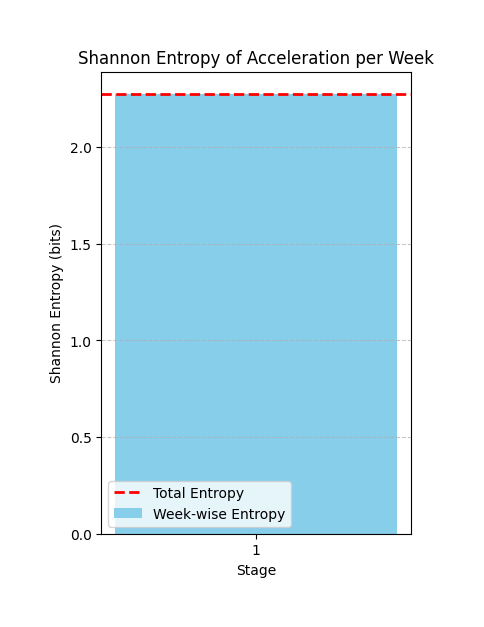

In [ ]:
# ------------------------- Shannon Entropy of Acceleration per Week



# --- 1. Shannon entropy for total acceleration ---
acc_total = combined_matrix['TotAccelBA'].values
counts, _ = np.histogram(acc_total, bins=10, density=True)
probabilities = counts / counts.sum()
shannon_entropy_total = entropy(probabilities, base=2)
print("Shannon Entropy (Total):", shannon_entropy_total)

# --- 2. Shannon entropy per week ---
week_entropies = {}
count = 1
for week, group in combined_matrix.groupby('Week_Number'):
    acc_week = group['TotAccelBA'].values
    counts, _ = np.histogram(acc_week, bins=10, density=True)
    probabilities = counts / counts.sum()
    week_entropy = entropy(probabilities, base=2)
    week_entropies[count] = week_entropy
    count += 1

# --- 3. Convert to Series for plotting ---
week_entropy_series = pd.Series(week_entropies).sort_index()

# --- 4. Plot using bar graph ---
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(week_entropy_series.index, week_entropy_series.values, color='skyblue', label='Week-wise Entropy')
ax.axhline(shannon_entropy_total, color='red', linestyle='--', linewidth=2, label='Total Entropy')
ax.set_xlabel('Stage')
ax.set_ylabel('Shannon Entropy (bits)')
ax.set_xticks(combined_matrix["Week_Number"].unique())
ax.set_title('Shannon Entropy of Acceleration per Week')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)


png_dir = os.path.join( output_dir , r'AccelerationEntropy' )
os.makedirs(png_dir, exist_ok=True)
    
base_filename = f"Acceleration_Shannon_Entropy"

png_path = os.path.join(png_dir, base_filename + ".png")
fig.savefig(png_path, dpi=300, bbox_inches='tight')  # save as PNG
print(f"PNG saved to: {png_path}")

plt.show()




In [ ]:
from matplotlib.ticker import MaxNLocator          # for integer y-axis ticks
import matplotlib.ticker as mticker               # for FormatStrFormatter (% formatting)

def create_cluster_usage_line_charts(combined_matrix, save=False, output_dir=None):
    df = combined_matrix.copy()
    df = df.dropna(subset=['Cluster', 'Week_Number'])
    clusters = sorted(df['Cluster'].unique())
    weeks_order = sorted(df['Week_Number'].unique())
    week_labels = [f'Week {int(w)}' for w in weeks_order]

    if len(clusters) == 0:
        raise ValueError("No clusters found in combined_matrix to plot.")

    if save and output_dir:
        chart_output_dir = os.path.join(output_dir, 'cluster_usage_line_plots')
        os.makedirs(chart_output_dir, exist_ok=True)

    # --- total observations per week (denominator for %) ---
    week_totals = df['Week_Number'].value_counts().reindex(weeks_order, fill_value=1)

    # --- build CSV: one row per cluster, one column per week ---
    csv_rows = []
    for cluster in clusters:
        cluster_df = df[df['Cluster'] == cluster]
        counts = cluster_df['Week_Number'].value_counts().reindex(weeks_order, fill_value=0)
        pct = (counts / week_totals * 100).round(2)

        row = {'Cluster': int(cluster)}
        for week, p in zip(weeks_order, pct.values):
            row[f'Week_{int(week)}_pct'] = p
        csv_rows.append(row)

    usage_df = pd.DataFrame(csv_rows)

    if save and output_dir:
        csv_path = os.path.join(chart_output_dir, 'cluster_usage_by_week.csv')
        usage_df.to_csv(csv_path, index=False)
        print(f'Saved CSV to: {csv_path}')

    # --- compute global y maximum across all clusters ---
    all_pcts = []
    for cluster in clusters:
        cluster_df = df[df['Cluster'] == cluster]
        counts = cluster_df['Week_Number'].value_counts().reindex(weeks_order, fill_value=0)
        pct = (counts / week_totals * 100).values
        all_pcts.extend(pct)

    y_max = max(all_pcts) * 1.1  # 10% headroom above the highest point

    # --- one line plot per cluster ---
    for cluster in clusters:
        cluster_df = df[df['Cluster'] == cluster]
        counts = cluster_df['Week_Number'].value_counts().reindex(weeks_order, fill_value=0)
        pct = (counts / week_totals * 100).values

        fig, ax = plt.subplots(figsize=(8, 4))

        # --- split into connected and special weeks ---
        special_weeks = {25: 'L-Dopa', 26: 'Saline'}
        connected_mask = [w not in special_weeks for w in weeks_order]
        special_mask   = {w: label for w, label in special_weeks.items() if w in weeks_order}

        connected_x = [lbl for lbl, keep in zip(week_labels, connected_mask) if keep]
        connected_y = [p   for p,   keep in zip(pct,         connected_mask) if keep]

        # --- plot connected line for normal weeks ---
        ax.plot(connected_x, connected_y, marker='o', linewidth=2,
                markersize=6, color='steelblue', label='Weekly usage')
        ax.fill_between(connected_x, connected_y, alpha=0.15, color='steelblue')

        # --- plot special weeks as isolated dots, same color as regular ---
        for week, label in special_mask.items():
            week_idx = weeks_order.index(week)
            week_label = f'Week {int(week)}'
            ax.scatter(week_label, pct[week_idx], color='steelblue', s=60, zorder=5)

        ax.set_title(f'Cluster {int(cluster)} — Usage by Week', fontsize=13)
        ax.set_xlabel('Week', fontsize=11)
        ax.set_ylabel('Usage (%)', fontsize=11)
        ax.set_xticks(range(len(week_labels)))

        # --- rename week 25/26 labels on x-axis ---
        special_label_map = {'Week 25': 'L-Dopa', 'Week 26': 'Saline'}
        display_labels = [special_label_map.get(lbl, lbl) for lbl in week_labels]
        ax.set_xticklabels(display_labels, rotation=45, ha='right', fontsize=9)

        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.spines[['top', 'right']].set_visible(False)
        ax.legend(fontsize=9, frameon=False)
        ax.set_ylim(0, y_max)

        plt.tight_layout()

        if save and output_dir:
            png_path = os.path.join(chart_output_dir, f'cluster_{int(cluster)}_usage_by_week.png')
            svg_path = os.path.join(chart_output_dir, f'cluster_{int(cluster)}_usage_by_week.svg')
            fig.savefig(png_path, dpi=150, bbox_inches='tight')
            fig.savefig(svg_path, bbox_inches='tight', format='svg')
            print(f'Saved cluster {int(cluster)} to: {png_path}')

        plt.show()
        plt.close(fig)

In [ ]:
create_cluster_usage_line_charts(combined_matrix, save=True, output_dir=output_dir)

In [ ]:
import scipy
df = combined_matrix.copy()
df = df.dropna(subset=['Cluster', 'Week_Number'])

clusters = sorted(df['Cluster'].unique())
weeks_order = sorted(df['Week_Number'].unique())

week_labels = [f'Week {int(w)}' for w in weeks_order]
week_totals = df['Week_Number'].value_counts().reindex(
    weeks_order,
    fill_value=1
)

special_label_map = {
    'Week 25': 'L-Dopa',
    'Week 26': 'Saline'
}

display_labels = [
    special_label_map.get(lbl, lbl)
    for lbl in week_labels
]

# --- identify downward trending clusters using linear regression slope ---
cluster_slopes = {}

for cluster in clusters:
    cluster_df = df[df['Cluster'] == cluster]

    counts = (
        cluster_df['Week_Number']
        .value_counts()
        .reindex(weeks_order, fill_value=0)
    )

    pct = (counts / week_totals * 100).values

    slope, _, _, _, _ = scipy.stats.linregress(
        range(len(weeks_order)),
        pct
    )
    cluster_slopes[cluster] = slope

print(f"Max Slope: {max(cluster_slopes.values())}")
print(f"Min Slope: {min(cluster_slopes.values())}")



In [ ]:

cluster_slopes = dict(sorted(cluster_slopes.items(), key=lambda item: item[1]))
ticklabels = [str(int(k)) for k in cluster_slopes.keys()]
fig, ax = plt.subplots(figsize=(10,6))

positions = range(1, len(cluster_slopes) + 1)
ax.bar(positions, cluster_slopes.values(), color='skyblue', label='Week-wise Entropy')
ax.set_xlabel('Stage')
ax.set_ylabel('Slope')

ax.set_xticks(positions)
ax.set_xticklabels(ticklabels)
ax.set_xticklabels(ticklabels, rotation=90)
ax.set_title('Cluster Usage By Week Slopes')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)



plt.show()

In [ ]:

def plot_downward_trend_clusters(
    combined_matrix,
    save=False,
    output_dir=None,
    percentage_limit=0
):
    df = combined_matrix.copy()
    df = df.dropna(subset=['Cluster', 'Week_Number'])

    clusters = sorted(df['Cluster'].unique())
    weeks_order = sorted(df['Week_Number'].unique())

    week_labels = [f'Week {int(w)}' for w in weeks_order]
    week_totals = df['Week_Number'].value_counts().reindex(
        weeks_order,
        fill_value=1
    )

    special_label_map = {
        'Week 25': 'L-Dopa',
        'Week 26': 'Saline'
    }

    display_labels = [
        special_label_map.get(lbl, lbl)
        for lbl in week_labels
    ]

    # --- identify downward trending clusters using linear regression slope ---
    downward_clusters = []
    downward_pcts = {}

    for cluster in clusters:
        cluster_df = df[df['Cluster'] == cluster]

        counts = (
            cluster_df['Week_Number']
            .value_counts()
            .reindex(weeks_order, fill_value=0)
        )

        pct = (counts / week_totals * 100).values

        slope, _, _, _, _ = scipy.stats.linregress(
            range(len(weeks_order)),
            pct
        )

        if slope < percentage_limit:
            downward_clusters.append(cluster)
            downward_pcts[cluster] = pct

    if len(downward_clusters) == 0:
        print("No clusters with downward trends found.")
        return

    print(
        f"Found {len(downward_clusters)} clusters "
        f"with downward trends: {downward_clusters}"
    )

    # --- plot all downward clusters on one graph ---
    cmap = plt.get_cmap('tab20')

    fig, ax = plt.subplots(figsize=(10, 5))

    special_weeks = {25, 26}

    connected_mask = [
        w not in special_weeks
        for w in weeks_order
    ]

    connected_x = [
        lbl
        for lbl, keep in zip(display_labels, connected_mask)
        if keep
    ]

    for i, cluster in enumerate(downward_clusters):
        pct = downward_pcts[cluster]

        color = cmap(
            i / max(len(downward_clusters) - 1, 1)
        )

        connected_y = [
            p
            for p, keep in zip(pct, connected_mask)
            if keep
        ]

        ax.plot(
            connected_x,
            connected_y,
            marker='o',
            linewidth=1.5,
            markersize=4,
            color=color,
            label=f'Cluster {int(cluster)}'
        )

        # isolated dots for special weeks
        for week in special_weeks:
            if week in weeks_order:
                week_idx = weeks_order.index(week)

                week_label = special_label_map.get(
                    f'Week {int(week)}',
                    f'Week {int(week)}'
                )

                ax.scatter(
                    week_label,
                    pct[week_idx],
                    color=color,
                    s=40,
                    zorder=5
                )

    ax.set_title(
        'Clusters with Downward Trends — Usage by Week',
        fontsize=13
    )

    ax.set_xlabel('Week', fontsize=11)
    ax.set_ylabel('Usage (%)', fontsize=11)

    ax.set_xticks(range(len(display_labels)))
    ax.set_xticklabels(
        display_labels,
        rotation=45,
        ha='right',
        fontsize=9
    )

    ax.yaxis.set_major_formatter(
        mticker.FormatStrFormatter('%.1f%%')
    )

    ax.yaxis.set_major_locator(
        mticker.MaxNLocator(nbins=6)
    )

    ax.set_ylim(0, None)

    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.5
    )

    ax.spines[['top', 'right']].set_visible(False)

    ax.legend(
        fontsize=8,
        frameon=False,
        bbox_to_anchor=(1.01, 1),
        loc='upper left'
    )

    plt.tight_layout()

    if save and output_dir:
        chart_output_dir = os.path.join(
            output_dir,
            'cluster_usage_line_plots',
            'downward'
        )

        os.makedirs(
            chart_output_dir,
            exist_ok=True
        )

        png_path = os.path.join(
            chart_output_dir,
            'downward_trend_clusters.png'
        )

        svg_path = os.path.join(
            chart_output_dir,
            'downward_trend_clusters.svg'
        )

        fig.savefig(
            png_path,
            dpi=150,
            bbox_inches='tight'
        )

        fig.savefig(
            svg_path,
            bbox_inches='tight',
            format='svg'
        )

        print(f'Saved to: {png_path}')

    plt.show()
    plt.close(fig)

In [ ]:
plot_downward_trend_clusters(combined_matrix, save=True, output_dir=output_dir, percentage_limit=-1)

In [ ]:
import scipy

def plot_upward_trend_clusters(
    combined_matrix,
    save=False,
    output_dir=None,
    percentage_limit=0
):
    df = combined_matrix.copy()
    df = df.dropna(subset=['Cluster', 'Week_Number'])

    clusters = sorted(df['Cluster'].unique())
    weeks_order = sorted(df['Week_Number'].unique())

    week_labels = [f'Week {int(w)}' for w in weeks_order]
    week_totals = df['Week_Number'].value_counts().reindex(
        weeks_order,
        fill_value=1
    )

    special_label_map = {
        'Week 25': 'L-Dopa',
        'Week 26': 'Saline'
    }

    display_labels = [
        special_label_map.get(lbl, lbl)
        for lbl in week_labels
    ]

    # --- identify downward trending clusters using linear regression slope ---
    downward_clusters = []
    downward_pcts = {}

    for cluster in clusters:
        cluster_df = df[df['Cluster'] == cluster]

        counts = (
            cluster_df['Week_Number']
            .value_counts()
            .reindex(weeks_order, fill_value=0)
        )

        pct = (counts / week_totals * 100).values

        slope, _, _, _, _ = scipy.stats.linregress(
            range(len(weeks_order)),
            pct
        )

        if slope > percentage_limit:
            downward_clusters.append(cluster)
            downward_pcts[cluster] = pct

    if len(downward_clusters) == 0:
        print("No clusters with upward trends found.")
        return

    print(
        f"Found {len(downward_clusters)} clusters "
        f"with upward trends: {downward_clusters}"
    )

    # --- plot all downward clusters on one graph ---
    cmap = plt.get_cmap('tab20')

    fig, ax = plt.subplots(figsize=(10, 5))

    special_weeks = {25, 26}

    connected_mask = [
        w not in special_weeks
        for w in weeks_order
    ]

    connected_x = [
        lbl
        for lbl, keep in zip(display_labels, connected_mask)
        if keep
    ]

    for i, cluster in enumerate(downward_clusters):
        pct = downward_pcts[cluster]

        color = cmap(
            i / max(len(downward_clusters) - 1, 1)
        )

        connected_y = [
            p
            for p, keep in zip(pct, connected_mask)
            if keep
        ]

        ax.plot(
            connected_x,
            connected_y,
            marker='o',
            linewidth=1.5,
            markersize=4,
            color=color,
            label=f'Cluster {int(cluster)}'
        )

        # isolated dots for special weeks
        for week in special_weeks:
            if week in weeks_order:
                week_idx = weeks_order.index(week)

                week_label = special_label_map.get(
                    f'Week {int(week)}',
                    f'Week {int(week)}'
                )

                ax.scatter(
                    week_label,
                    pct[week_idx],
                    color=color,
                    s=40,
                    zorder=5
                )

    ax.set_title(
        'Clusters with Upward Trends — Usage by Week',
        fontsize=13
    )

    ax.set_xlabel('Week', fontsize=11)
    ax.set_ylabel('Usage (%)', fontsize=11)

    ax.set_xticks(range(len(display_labels)))
    ax.set_xticklabels(
        display_labels,
        rotation=45,
        ha='right',
        fontsize=9
    )

    ax.yaxis.set_major_formatter(
        mticker.FormatStrFormatter('%.1f%%')
    )

    ax.yaxis.set_major_locator(
        mticker.MaxNLocator(nbins=6)
    )

    ax.set_ylim(0, None)

    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.5
    )

    ax.spines[['top', 'right']].set_visible(False)

    ax.legend(
        fontsize=8,
        frameon=False,
        bbox_to_anchor=(1.01, 1),
        loc='upper left'
    )

    plt.tight_layout()

    if save and output_dir:
        chart_output_dir = os.path.join(
            output_dir,
            'cluster_usage_line_plots',
            'upward'
        )

        os.makedirs(
            chart_output_dir,
            exist_ok=True
        )

        png_path = os.path.join(
            chart_output_dir,
            'upward_trend_clusters.png'
        )

        svg_path = os.path.join(
            chart_output_dir,
            'upward_trend_clusters.svg'
        )

        fig.savefig(
            png_path,
            dpi=150,
            bbox_inches='tight'
        )

        fig.savefig(
            svg_path,
            bbox_inches='tight',
            format='svg'
        )

        print(f'Saved to: {png_path}')

    plt.show()
    plt.close(fig)

In [ ]:
plot_upward_trend_clusters(combined_matrix, save=True, output_dir=output_dir, percentage_limit=1)

In [ ]:
import scipy

def plot_sustaining_trend_clusters(
    combined_matrix,
    save=False,
    output_dir=None,
    percentage_limit=(-0.05, 0.05)
):
    df = combined_matrix.copy()
    df = df.dropna(subset=['Cluster', 'Week_Number'])

    clusters = sorted(df['Cluster'].unique())
    weeks_order = sorted(df['Week_Number'].unique())

    week_labels = [f'Week {int(w)}' for w in weeks_order]
    week_totals = df['Week_Number'].value_counts().reindex(
        weeks_order,
        fill_value=1
    )

    special_label_map = {
        'Week 25': 'L-Dopa',
        'Week 26': 'Saline'
    }

    display_labels = [
        special_label_map.get(lbl, lbl)
        for lbl in week_labels
    ]

    # --- identify downward trending clusters using linear regression slope ---
    downward_clusters = []
    downward_pcts = {}

    for cluster in clusters:
        cluster_df = df[df['Cluster'] == cluster]

        counts = (
            cluster_df['Week_Number']
            .value_counts()
            .reindex(weeks_order, fill_value=0)
        )

        pct = (counts / week_totals * 100).values

        slope, _, _, _, _ = scipy.stats.linregress(
            range(len(weeks_order)),
            pct
        )

        if slope > percentage_limit[0] and slope < percentage_limit[1]:
            downward_clusters.append(cluster)
            downward_pcts[cluster] = pct

    if len(downward_clusters) == 0:
        print("No clusters with sustaining trends found.")
        return

    print(
        f"Found {len(downward_clusters)} clusters "
        f"with sustaining trends: {downward_clusters}"
    )

    # --- plot all downward clusters on one graph ---
    cmap = plt.get_cmap('tab20')

    fig, ax = plt.subplots(figsize=(10, 5))

    special_weeks = {25, 26}

    connected_mask = [
        w not in special_weeks
        for w in weeks_order
    ]

    connected_x = [
        lbl
        for lbl, keep in zip(display_labels, connected_mask)
        if keep
    ]

    for i, cluster in enumerate(downward_clusters):
        pct = downward_pcts[cluster]

        color = cmap(
            i / max(len(downward_clusters) - 1, 1)
        )

        connected_y = [
            p
            for p, keep in zip(pct, connected_mask)
            if keep
        ]

        ax.plot(
            connected_x,
            connected_y,
            marker='o',
            linewidth=1.5,
            markersize=4,
            color=color,
            label=f'Cluster {int(cluster)}'
        )

        # isolated dots for special weeks
        for week in special_weeks:
            if week in weeks_order:
                week_idx = weeks_order.index(week)

                week_label = special_label_map.get(
                    f'Week {int(week)}',
                    f'Week {int(week)}'
                )

                ax.scatter(
                    week_label,
                    pct[week_idx],
                    color=color,
                    s=40,
                    zorder=5
                )

    ax.set_title(
        'Clusters with Sustaining Trends — Usage by Week',
        fontsize=13
    )

    ax.set_xlabel('Week', fontsize=11)
    ax.set_ylabel('Usage (%)', fontsize=11)

    ax.set_xticks(range(len(display_labels)))
    ax.set_xticklabels(
        display_labels,
        rotation=45,
        ha='right',
        fontsize=9
    )

    ax.yaxis.set_major_formatter(
        mticker.FormatStrFormatter('%.1f%%')
    )

    ax.yaxis.set_major_locator(
        mticker.MaxNLocator(nbins=6)
    )

    ax.set_ylim(0, None)

    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.5
    )

    ax.spines[['top', 'right']].set_visible(False)

    ax.legend(
        fontsize=8,
        frameon=False,
        bbox_to_anchor=(1.01, 1),
        loc='upper left'
    )

    plt.tight_layout()

    if save and output_dir:
        chart_output_dir = os.path.join(
            output_dir,
            'cluster_usage_line_plots',
            'sustain'
        )

        os.makedirs(
            chart_output_dir,
            exist_ok=True
        )

        png_path = os.path.join(
            chart_output_dir,
            'sustaining_trend_clusters.png'
        )

        svg_path = os.path.join(
            chart_output_dir,
            'sustaining_trend_clusters.svg'
        )

        fig.savefig(
            png_path,
            dpi=150,
            bbox_inches='tight'
        )

        fig.savefig(
            svg_path,
            bbox_inches='tight',
            format='svg'
        )

        print(f'Saved to: {png_path}')

    plt.show()
    plt.close(fig)

In [ ]:
plot_sustaining_trend_clusters(combined_matrix, save=True, output_dir=output_dir, percentage_limit=(-0.4, 0.4))

In [ ]:
# ------------------------ Dendograms ----------------------------

# Load MATLAB linkage matrix
Z = np.loadtxt(linkage_matrix_path, delimiter=",")

threshold = Z[0,0]
Z = Z[1:,:]
def add_sample_counts(Z):
    """
    Add the 4th column (cluster sizes) required by SciPy dendrogram.
    Assumes Z is (n-1, 3) with 0-based indices.
    """
    Z = Z.copy()
    n = Z.shape[0] + 1

    # Create leaf labels starting at 1
    

    counts = np.zeros(Z.shape[0], dtype=int)

    for i in range(Z.shape[0]):
        c1, c2 = int(Z[i, 0]), int(Z[i, 1])

        def cluster_size(c):
            if c < n:
                return 1
            else:
                return counts[c - n]

        counts[i] = cluster_size(c1) + cluster_size(c2)

    return np.column_stack([Z, counts])


# Convert MATLAB (1-based) → Python (0-based)
Z[:, 0:2] -= 1

# Add 4th column
Z = add_sample_counts(Z)


# Plot dendrogram
plt.figure(figsize=(10, 6))

# Make cluster labels 1 to n instead of 0 to n - 1 (inclusive)
n = Z.shape[0] + 1
leaf_labels = np.arange(1, n+1)  # [1, 2, 3, ..., n]
dendrogram(Z, labels=leaf_labels)

plt.axhline(y=threshold, color="red", linestyle="--", linewidth=1)
plt.title("Recreated MATLAB Dendrogram")
plt.xlabel("Cluster index")
plt.ylabel("Distance")

png_dir = os.path.join( output_dir , r'Dendograms' )
os.makedirs(png_dir, exist_ok=True)
    
base_filename = f"Dendogram"

png_path = os.path.join(png_dir, base_filename + ".png")
plt.savefig(png_path, dpi=300, bbox_inches='tight')  # save as PNG
print(f"PNG saved to: {png_path}")

plt.show()


In [ ]:
# ------------------------ Dendograms ----------------------------

# df = combined_matrix

Z_levels = Z.copy()
max_distance = np.max(Z[:, 2])
# Example custom thresholds (distance values)
custom_thresholds = [threshold, threshold*2, threshold*4, threshold*8]  # 4 thresholds for 5 levels
custom_thresholds = np.linspace(threshold, max_distance*0.5, 4, endpoint=False)

# Make sure they are sorted ascending
custom_thresholds = np.sort(custom_thresholds)
# Assign each merge to a level 1–5 based on custom thresholds
for i in range(Z_levels.shape[0]):
    dist = Z_levels[i, 2]
    level = np.sum(dist > custom_thresholds) + 1  # level from 1 to 5
    Z_levels[i, 2] = level


In [ ]:
# ------------------------ Dendograms ----------------------------
#cluster_acc = df.groupby('Cluster')['TotAccelBA'].mean()
cluster_acc = combined_matrix.groupby('Cluster').size()
# Count how many leaves are in each cluster
cluster_counts = combined_matrix.groupby('Cluster').size()

# Convert to percentage
cluster_percent = cluster_counts / cluster_counts.sum() * 100

cluster_acc = cluster_percent

In [ ]:
# ------------------------ Dendograms ----------------------------
def get_dendogram_color_data(dendrogram_data, all_segments, final_colors):
    leaf_order = dendrogram_data['leaves']
    leaf_x_positions = []
    leaf_colors = []

    for seg, color in zip(all_segments, final_colors):
        
        # If the segment touches the bottom
        if np.any(np.isclose(seg[:, 1], 0)):
            
            # Find x coordinate at y = 0
            bottom_points = seg[np.isclose(seg[:, 1], 0)]
            
            for pt in bottom_points:
                leaf_x_positions.append(pt[0])
                leaf_colors.append(color)

    # Convert to arrays
    leaf_x_positions = np.array(leaf_x_positions)
    leaf_colors = np.array(leaf_colors)

    # Remove duplicates (multiple points can exist per leaf)
    unique_x, unique_indices = np.unique(leaf_x_positions, return_index=True)

    leaf_x_positions = unique_x
    leaf_colors = leaf_colors[unique_indices]

    # Sort left → right
    sort_idx = np.argsort(leaf_x_positions)
    leaf_x_positions = leaf_x_positions[sort_idx]
    leaf_colors = leaf_colors[sort_idx]

    # Build DataFrame
    df_leaf_colors = pd.DataFrame({
        "LeafIndex": leaf_order,
        "ClusterLabel": combined_matrix['Cluster'].values[leaf_order],
        "XPosition": leaf_x_positions,
        "RGBA_Color": list(leaf_colors)
    })

    df_leaf_colors["HEX_Color"] = df_leaf_colors["RGBA_Color"].apply(to_hex)
    return df_leaf_colors



In [ ]:
# ------------------------ Dendograms ----------------------------


def dendogram_plot_with_usage(save_path, cluster_data, addon="", max_val=None, save=False):
    fig, (ax_dendro, ax_bar) = plt.subplots(
        2, 1,
        figsize=(10, 4),
        gridspec_kw={'height_ratios': [3, 2]},
        sharex=True
    )

    # -----------------------------
    # DENDROGRAM 
    # -----------------------------
    ddata = dendrogram(Z_levels, ax=ax_dendro, labels = leaf_labels)



    # Get ALL dendrogram line collections
    line_collections = [c for c in ax_dendro.collections if isinstance(c, LineCollection)]

    # Gather all segments
    all_segments = []
    segment_map = []

    for lc in line_collections:
        segments = lc.get_segments()
        for seg in segments:
            all_segments.append(seg)
            segment_map.append(lc)

    # Identify vertical segments and store their indices
    vertical_indices = []
    vertical_x = []

    for i, seg in enumerate(all_segments):
        # A segment is vertical if x values are equal
        if np.allclose(seg[0, 0], seg[1, 0]):
            vertical_indices.append(i)
            vertical_x.append(seg[0, 0])

    vertical_x = np.array(vertical_x)

    # Normalize x positions (left → right)
    x_min = vertical_x.min()
    x_max = vertical_x.max()
    x_norm = (vertical_x - x_min) / (x_max - x_min)

    # Custom gradient
    cmap = LinearSegmentedColormap.from_list(
        "custom_gradient",
        ["#eec42b", "#61b751", "#2a84df", "#dd077a"]
    )

    # Create full color list (default gray for all)
    final_colors = [(0.7, 0.7, 0.7, 1)] * len(all_segments)

    # Assign gradient only to vertical segments
    for idx, norm_val in zip(vertical_indices, x_norm):
        final_colors[idx] = cmap(norm_val)

    # Apply colors back
    start = 0
    for lc in line_collections:
        lc.set_linewidth(2)
        seg_count = len(lc.get_segments())
        lc.set_color(final_colors[start:start + seg_count])
        start += seg_count

    # Styling
    ax_dendro.spines['bottom'].set_visible(False)
    ax_dendro.set_ylabel("Hierarchy Level")
    ax_dendro.set_yticks(range(1, 6))
    ax_dendro.set_yticklabels(list(range(5, 0, -1)))
    ax_dendro.set_title("5-Level Hierarchy Dendrogram" + addon)
    ax_dendro.tick_params(axis='x', length=0, labelsize=6)

    df_leaf_colors = get_dendogram_color_data(ddata, all_segments, final_colors)

    # -----------------------------
    # BAR GRAPH (ALIGNED TO LEAVES)
    # -----------------------------

    # 2️⃣ Map each leaf (in dendrogram order) to the cluster's mean
    leaf_order = ddata['leaves']
    ordered_clusters = combined_matrix['Cluster'].values[leaf_order]

    # Map cluster label → mean acceleration
    bar_values = []
    for label in leaf_order:
        label = label + 1
        if not label in cluster_data:
            bar_values.append(0)
            continue
        bar_values.append(cluster_data[label])

    # 3️⃣ Bar positions (aligned to dendrogram leaves)
    x_positions = np.arange(len(ordered_clusters)) * 10 + 5

    # 4️⃣ Plot
    bar_colors = df_leaf_colors["RGBA_Color"].tolist()  # keep colors
    ax_bar.bar(x_positions, bar_values, width=8, color=bar_colors)

    ax_bar.set_ylabel("Cluster Usage %")
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    ax_bar.invert_yaxis()  # optional
    ax_bar.xaxis.set_visible(False)
    #ax_bar.spines['bottom'].set_visible(False)
    #ax_bar.set_ylim(6 * 1.1)
    if max_val:
        ax_bar.set_ylim(max_val * 1.1)
    
    # Save as PNG
    if save:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.tight_layout()
    plt.show()
    return max(bar_values)

In [ ]:
# ------------------------ Dendograms ----------------------------
stages = []
week_numbers = combined_matrix["Week_Number"].unique()
week_numbers = sorted(week_numbers, reverse=False)

for week in week_numbers:
    week_data = combined_matrix[combined_matrix["Week_Number"] == week]
    stages.append(week_data)

In [ ]:
# ------------------------ Dendograms ----------------------------

max_val = None
for i in range(len(stages)+1):
    if i == 0:
        base_filename = "Hierarchy_Dendogram_Usage"
        cluster_acc = combined_matrix.groupby('Cluster').size()
        # Count how many leaves are in each cluster
        cluster_counts = combined_matrix.groupby('Cluster').size()
        cluster_acc = combined_matrix.groupby('Cluster')['TotAccelBA'].mean()
        addon=" Combined"
    else:
        base_filename = f"Hierarchy_Dendogram_Usage_Stage_{i}"
        cluster_acc = stages[i-1].groupby('Cluster').size()
        # Count how many leaves are in each cluster
        cluster_counts = stages[i-1].groupby('Cluster').size()
        cluster_acc = stages[i-1].groupby('Cluster')['TotAccelBA'].mean()
        addon=f" In Stage {i}"

    # Convert to percentage
    cluster_percent = cluster_counts / cluster_counts.sum() * 100

    png_path = os.path.join(png_dir, base_filename + ".png")
    dendogram_plot_with_usage(png_path, cluster_percent, addon=addon, save=True)